# Multi-Segment Analysis Hub

This notebook consolidates the analysis workflow into one place.

Sections:
- task-level gaze speed distributions
- batch result summaries across `fps / caption / gaze annotation` configs
- Savitzky-Golay sweep analysis for `w/ live caption + w/o gaze annotation`
- representative-frame method comparison
- interactive episode browser with GT / prediction overlays and debug clips

The older analysis notebooks were folded into this notebook. `export_vrs.ipynb` is left untouched because it is unrelated.


---

## Task-Level Gaze Distribution


# Gaze Speed Distribution by Task

This notebook loads `gaze.json`, `labels.npy`, and `segments.json` from `dataset/`, computes frame-aligned angular gaze speed in `deg/s`, and visualizes:
- task-wise gaze speed histograms inside labeled frames (`labels == 1`)
- ordered-label segment-duration histograms for the multi-segment tasks

Ordered labels are defined by segment order in time:
- first labeled segment -> `label 1`
- second labeled segment -> `label 2`

For `single_object_pick_place` and `double_object_pickup`, the duration plots below mean segment length in seconds, for example `0.4s`, `1.2s`, `2.0s`.


In [74]:
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import savgol_filter

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

DATASET_DIR = Path("dataset")
DEFAULT_FPS = 15.0

TASK_CONFIGS = {
    "Single Object Pickup": "2f_store_dongjun_setup_single_object_pickup",
    "Single Object Pick Place": "2f_store_juheon_setup_single_object_pick_place",
    "Double Object Pickup": "2f_store_juheon_setup_double_object_pickup",
}

TASK_COLORS = {
    "Single Object Pickup": "#1f77b4",
    "Single Object Pick Place": "#ff7f0e",
    "Double Object Pickup": "#2ca02c",
}

ORDERED_LABEL_COLORS = {
    1: "#2563eb",
    2: "#dc2626",
}

TASK_ORDER = list(TASK_CONFIGS.keys())
MULTI_SEGMENT_TASKS = [
    "Single Object Pick Place",
    "Double Object Pickup",
]


In [75]:
def compute_angular_velocity(pitch_yaw: np.ndarray, fps: float, savgol_window: int = 11, savgol_poly: int = 2) -> np.ndarray:
    """Compute frame-aligned gaze angular velocity in deg/s.

    This follows the same definition used in `data_loader.py`.
    """
    pitch = pitch_yaw[:, 0]
    yaw = pitch_yaw[:, 3]

    total_frames = len(pitch)
    if total_frames <= 1 or fps <= 0:
        return np.zeros(total_frames, dtype=np.float64)

    if total_frames < savgol_window:
        savgol_window = total_frames if total_frames % 2 == 1 else total_frames - 1
    savgol_window = max(savgol_window, 3)

    if savgol_poly >= savgol_window:
        savgol_poly = savgol_window - 1

    pitch_s = savgol_filter(pitch, savgol_window, savgol_poly)
    yaw_s = savgol_filter(yaw, savgol_window, savgol_poly)

    x = np.cos(pitch_s) * np.cos(yaw_s)
    y = np.cos(pitch_s) * np.sin(yaw_s)
    z = np.sin(pitch_s)

    step_dot = np.clip(
        x[:-1] * x[1:] + y[:-1] * y[1:] + z[:-1] * z[1:],
        -1.0,
        1.0,
    )
    step_velocity = np.arccos(step_dot) * fps

    angular_velocity = np.zeros(total_frames, dtype=np.float64)
    angular_velocity[0] = step_velocity[0]
    angular_velocity[-1] = step_velocity[-1]

    if total_frames > 2:
        center_dot = np.clip(
            x[:-2] * x[2:] + y[:-2] * y[2:] + z[:-2] * z[2:],
            -1.0,
            1.0,
        )
        angular_velocity[1:-1] = np.arccos(center_dot) * (fps / 2.0)

    return np.rad2deg(angular_velocity)


def discover_episodes(dataset_dir: Path, prefix: str) -> list[Path]:
    pattern = re.compile(rf"^{re.escape(prefix)}_(\d+)$")
    numbered = []

    for path in dataset_dir.iterdir():
        if not path.is_dir():
            continue
        match = pattern.match(path.name)
        if match and (path / "labels.npy").exists() and (path / "gaze.json").exists():
            numbered.append((int(match.group(1)), path))

    numbered.sort(key=lambda item: item[0])
    episodes = [path for _, path in numbered]

    exact = dataset_dir / prefix
    if exact.is_dir() and (exact / "labels.npy").exists() and (exact / "gaze.json").exists():
        episodes = [exact] + episodes

    return episodes


def extract_segments(frame_indices: np.ndarray) -> list[tuple[int, int]]:
    if len(frame_indices) == 0:
        return []

    frame_indices = [int(idx) for idx in frame_indices]
    segments = []
    start = frame_indices[0]
    prev = frame_indices[0]

    for current in frame_indices[1:]:
        if current != prev + 1:
            segments.append((start, prev))
            start = current
        prev = current

    segments.append((start, prev))
    return segments


def load_ordered_segments(episode_dir: Path, labels: np.ndarray) -> list[tuple[int, int]]:
    segments_path = episode_dir / "segments.json"
    if segments_path.exists():
        payload = json.loads(segments_path.read_text())
        raw_segments = payload.get("segments", []) if isinstance(payload, dict) else payload
        ordered_segments = []
        for segment in raw_segments:
            if not isinstance(segment, dict):
                continue
            if "start" not in segment or "end" not in segment:
                continue
            ordered_segments.append((int(segment["start"]), int(segment["end"])))
        ordered_segments.sort(key=lambda item: item[0])
        if ordered_segments:
            return ordered_segments

    positive_frames = np.flatnonzero(labels > 0)
    return extract_segments(positive_frames)


def load_episode_table(episode_dir: Path, task_label: str, task_prefix: str, default_fps: float = DEFAULT_FPS) -> pd.DataFrame:
    labels = np.load(episode_dir / "labels.npy").astype(np.int8)
    gaze_payload = json.loads((episode_dir / "gaze.json").read_text())
    frames = gaze_payload["frames"]

    if len(frames) != len(labels):
        raise ValueError(
            f"Length mismatch for {episode_dir.name}: gaze={len(frames)} labels={len(labels)}"
        )

    fps = default_fps
    ann_path = episode_dir / "annotations.json"
    if ann_path.exists():
        ann_payload = json.loads(ann_path.read_text())
        fps = float(ann_payload.get("fps") or fps)

    pitch_yaw = np.array(
        [
            [
                frame["pitch"],
                frame["pitch_lower"],
                frame["pitch_upper"],
                frame["yaw"],
                frame["yaw_lower"],
                frame["yaw_upper"],
            ]
            for frame in frames
        ],
        dtype=np.float64,
    )

    angular_speed_deg_s = compute_angular_velocity(pitch_yaw, fps=fps)
    ordered_segments = load_ordered_segments(episode_dir, labels)
    ordered_label_id = np.zeros(len(labels), dtype=np.int8)

    for label_id, (start, end) in enumerate(ordered_segments, start=1):
        ordered_label_id[start : end + 1] = label_id

    return pd.DataFrame(
        {
            "task": task_label,
            "task_prefix": task_prefix,
            "episode": episode_dir.name,
            "frame_idx": [int(frame["frame_idx"]) for frame in frames],
            "time_sec": np.arange(len(frames), dtype=np.float64) / fps,
            "fps": fps,
            "label": labels,
            "ordered_label_id": ordered_label_id,
            "angular_speed_deg_s": angular_speed_deg_s,
            "gaze_x": [float(frame["gaze_x"]) for frame in frames],
            "gaze_y": [float(frame["gaze_y"]) for frame in frames],
            "pitch": pitch_yaw[:, 0],
            "yaw": pitch_yaw[:, 3],
        }
    )


In [76]:
all_frames = []
episode_rows = []
segment_rows = []

for task_label, task_prefix in TASK_CONFIGS.items():
    episode_dirs = discover_episodes(DATASET_DIR, task_prefix)
    if not episode_dirs:
        raise FileNotFoundError(f"No episodes found for prefix: {task_prefix}")

    for episode_dir in episode_dirs:
        episode_df = load_episode_table(episode_dir, task_label, task_prefix)
        all_frames.append(episode_df)

        fps = float(episode_df["fps"].iloc[0])
        ordered_counts = episode_df.loc[episode_df["ordered_label_id"] > 0, "ordered_label_id"].value_counts()
        episode_rows.append(
            {
                "task": task_label,
                "episode": episode_dir.name,
                "frames": len(episode_df),
                "labeled_frames": int((episode_df["label"] > 0).sum()),
                "label_ratio": float((episode_df["label"] > 0).mean()),
                "ordered_segment_count": int(episode_df["ordered_label_id"].max()),
                "label_1_frames": int(ordered_counts.get(1, 0)),
                "label_2_frames": int(ordered_counts.get(2, 0)),
                "fps": fps,
            }
        )

        for ordered_label_id in sorted(episode_df["ordered_label_id"].unique()):
            if ordered_label_id == 0:
                continue

            frame_indices = episode_df.loc[
                episode_df["ordered_label_id"] == ordered_label_id,
                "frame_idx",
            ].to_numpy()

            for start_frame, end_frame in extract_segments(frame_indices):
                segment_rows.append(
                    {
                        "task": task_label,
                        "episode": episode_dir.name,
                        "ordered_label_id": int(ordered_label_id),
                        "start_frame": int(start_frame),
                        "end_frame": int(end_frame),
                        "start_sec": start_frame / fps,
                        "end_sec": end_frame / fps,
                        "duration_frames": int(end_frame - start_frame + 1),
                        "duration_sec": (end_frame - start_frame + 1) / fps,
                    }
                )

frames_df = pd.concat(all_frames, ignore_index=True)
frames_df["label_name"] = np.where(frames_df["label"] == 1, "labeled", "background")
episodes_df = pd.DataFrame(episode_rows)
segment_df = pd.DataFrame(segment_rows)

task_summary = (
    episodes_df.groupby("task", sort=False)
    .agg(
        episodes=("episode", "nunique"),
        total_frames=("frames", "sum"),
        labeled_frames=("labeled_frames", "sum"),
        mean_label_ratio=("label_ratio", "mean"),
        avg_ordered_segments=("ordered_segment_count", "mean"),
        fps_values=("fps", lambda series: ", ".join(sorted({f"{value:g}" for value in series}))),
    )
    .round(4)
)

display(task_summary)
display(episodes_df.head())

multi_segment_summary = (
    segment_df[segment_df["task"].isin(MULTI_SEGMENT_TASKS)]
    .groupby(["task", "ordered_label_id"], sort=False)
    .size()
    .rename("segments")
    .reset_index()
)
display(multi_segment_summary)


,episodes,total_frames,labeled_frames,mean_label_ratio,avg_ordered_segments,fps_values
task,,,,,,
Single Object Pickup,79,9135,849,0.1004,1.0000,15
Single Object Pick Place,49,5757,783,0.1379,1.9796,15
Double Object Pickup,73,8890,1371,0.1528,1.9863,15


,task,episode,frames,labeled_frames,label_ratio,ordered_segment_count,label_1_frames,label_2_frames,fps
0,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_1,211,4,0.018957,1,4,0,15.0
1,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_2,137,3,0.021898,1,3,0,15.0
2,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_3,106,15,0.141509,1,15,0,15.0
3,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_4,122,11,0.090164,1,11,0,15.0
4,Single Object Pickup,2f_store_dongjun_setup_single_object_pickup_5,115,12,0.104348,1,12,0,15.0


,task,ordered_label_id,segments
0,Single Object Pick Place,1,49
1,Single Object Pick Place,2,48
2,Double Object Pickup,1,73
3,Double Object Pickup,2,72


In [77]:
labeled_df = frames_df[frames_df["label"] == 1].copy()

task_speed_stats = (
    labeled_df.groupby("task", sort=False)["angular_speed_deg_s"]
    .agg(
        samples="count",
        mean="mean",
        median="median",
        std="std",
        p90=lambda series: series.quantile(0.90),
        p95=lambda series: series.quantile(0.95),
        max="max",
    )
    .round(2)
)

display(task_speed_stats)


,samples,mean,median,std,p90,p95,max
task,,,,,,,
Single Object Pickup,849,14.35,9.59,15.08,32.56,46.59,114.72
Single Object Pick Place,783,14.21,10.58,13.18,28.18,43.56,87.44
Double Object Pickup,1371,12.14,7.79,12.03,28.71,39.99,76.09


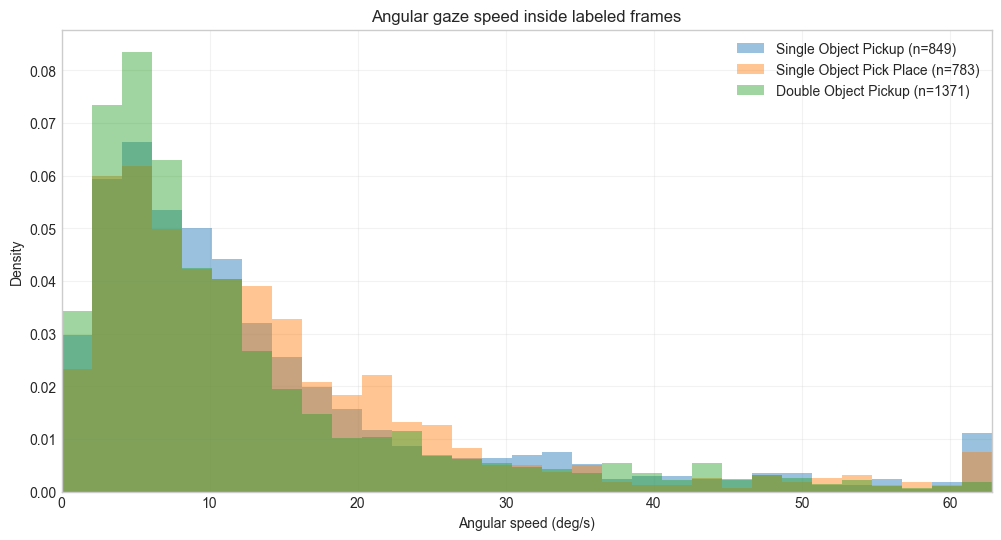

Histogram upper bound is clipped at the global 99th percentile: 62.79 deg/s


In [78]:
hist_max = float(labeled_df["angular_speed_deg_s"].quantile(0.99))
bins = np.linspace(0.0, hist_max, 32)

fig, ax = plt.subplots(figsize=(12, 6))
for task_label in TASK_ORDER:
    task_values = labeled_df.loc[
        labeled_df["task"] == task_label,
        "angular_speed_deg_s",
    ].clip(upper=hist_max)
    ax.hist(
        task_values,
        bins=bins,
        density=True,
        alpha=0.45,
        label=f"{task_label} (n={len(task_values)})",
        color=TASK_COLORS[task_label],
    )

ax.set_title("Angular gaze speed inside labeled frames")
ax.set_xlabel("Angular speed (deg/s)")
ax.set_ylabel("Density")
ax.set_xlim(0, hist_max)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f"Histogram upper bound is clipped at the global 99th percentile: {hist_max:.2f} deg/s")


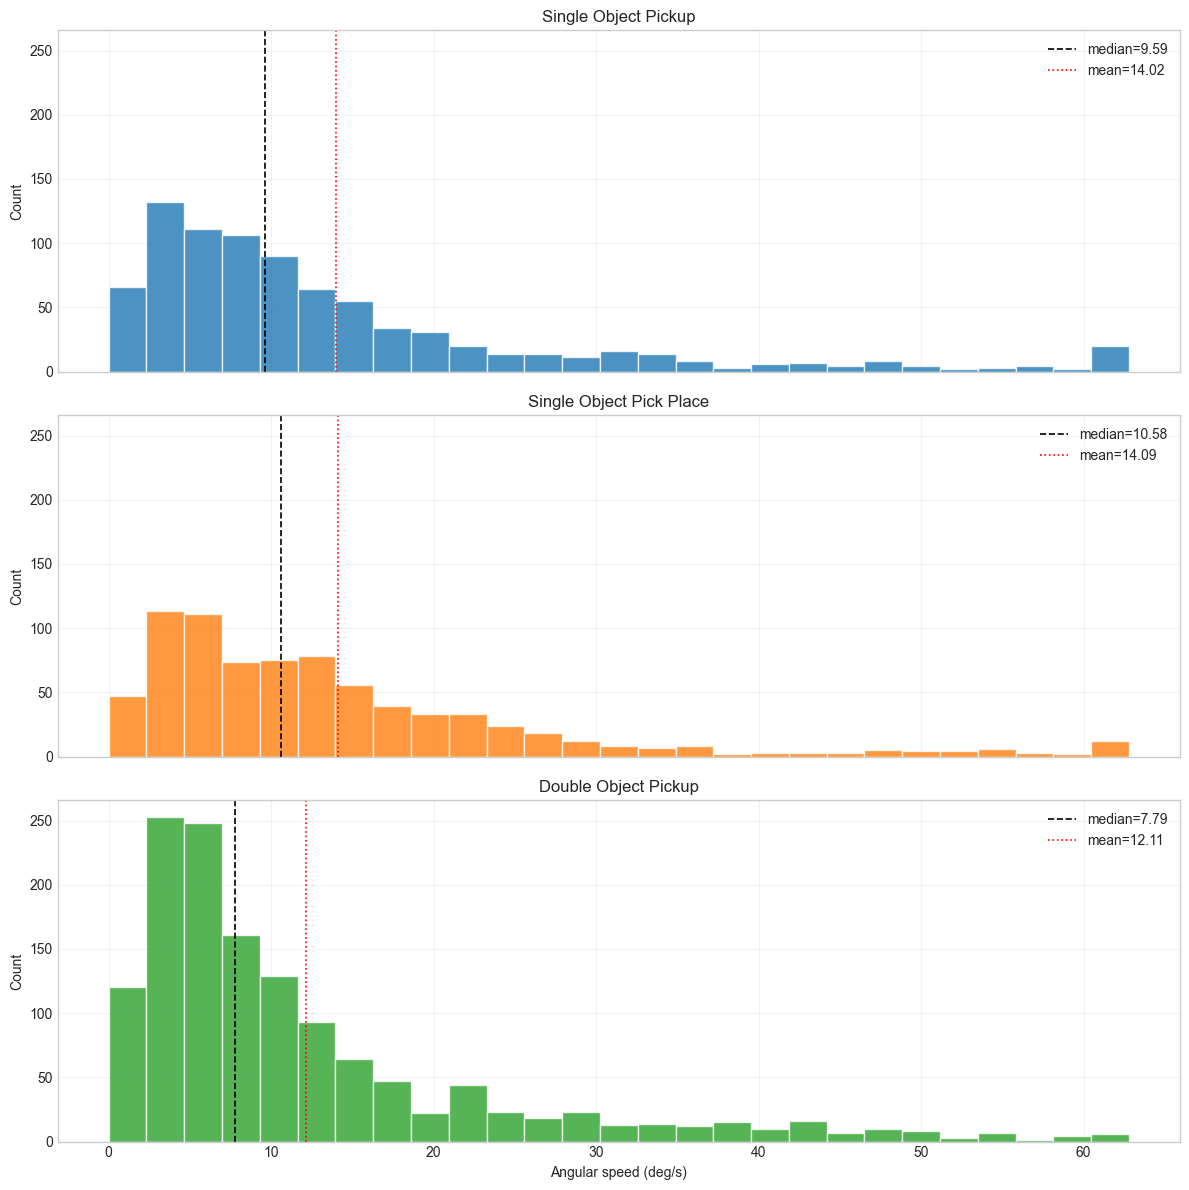

In [79]:
hist_max = float(labeled_df["angular_speed_deg_s"].quantile(0.99))
bins = np.linspace(0.0, hist_max, 28)

fig, axes = plt.subplots(len(TASK_ORDER), 1, figsize=(12, 12), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, task_label in zip(axes, TASK_ORDER):
    task_values = labeled_df.loc[
        labeled_df["task"] == task_label,
        "angular_speed_deg_s",
    ].clip(upper=hist_max)

    ax.hist(
        task_values,
        bins=bins,
        color=TASK_COLORS[task_label],
        alpha=0.8,
        edgecolor="white",
    )
    ax.axvline(task_values.median(), color="black", linestyle="--", linewidth=1.2, label=f"median={task_values.median():.2f}")
    ax.axvline(task_values.mean(), color="red", linestyle=":", linewidth=1.2, label=f"mean={task_values.mean():.2f}")
    ax.set_title(task_label)
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Angular speed (deg/s)")
plt.tight_layout()
plt.show()


In [80]:
ordered_segment_df = segment_df[segment_df["task"].isin(MULTI_SEGMENT_TASKS)].copy()

ordered_label_duration_stats = (
    ordered_segment_df.groupby(["task", "ordered_label_id"], sort=False)["duration_sec"]
    .agg(
        segments="count",
        mean="mean",
        median="median",
        p10=lambda series: series.quantile(0.10),
        p90=lambda series: series.quantile(0.90),
        min="min",
        max="max",
    )
    .round(3)
)

display(ordered_label_duration_stats)


segments   mean  median    p10    p90    min    max
task                     ordered_label_id                                                     
Single Object Pick Place 1                       49  0.585   0.533  0.267  1.000  0.133  1.400
                         2                       48  0.490   0.400  0.267  0.800  0.200  1.733
Double Object Pickup     1                       73  0.674   0.533  0.267  1.173  0.200  2.533
                         2                       72  0.586   0.467  0.267  1.060  0.200  1.867

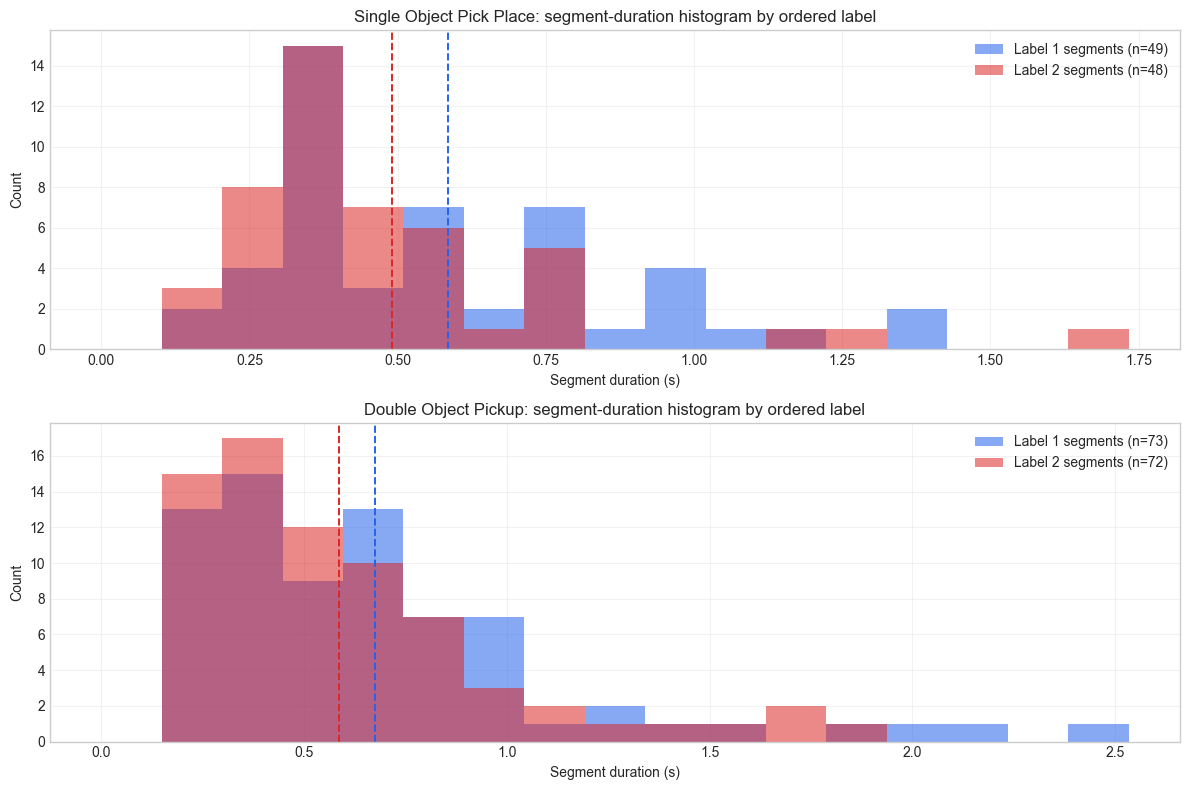

Label 1 = first labeled segment, Label 2 = later labeled segment


In [81]:
fig, axes = plt.subplots(len(MULTI_SEGMENT_TASKS), 1, figsize=(12, 8), sharex=False, sharey=False)
axes = np.atleast_1d(axes)

for ax, task_label in zip(axes, MULTI_SEGMENT_TASKS):
    task_df = ordered_segment_df[ordered_segment_df["task"] == task_label]
    if task_df.empty:
        continue

    duration_max = float(task_df["duration_sec"].max())
    bins = np.linspace(0.0, duration_max, 18)

    for ordered_label_id in [1, 2]:
        label_df = task_df[task_df["ordered_label_id"] == ordered_label_id]
        if label_df.empty:
            continue

        ax.hist(
            label_df["duration_sec"],
            bins=bins,
            alpha=0.55,
            color=ORDERED_LABEL_COLORS[ordered_label_id],
            label=f"Label {ordered_label_id} segments (n={len(label_df)})",
        )
        ax.axvline(
            label_df["duration_sec"].mean(),
            color=ORDERED_LABEL_COLORS[ordered_label_id],
            linestyle="--",
            linewidth=1.4,
        )

    ax.set_title(f"{task_label}: segment-duration histogram by ordered label")
    ax.set_xlabel("Segment duration (s)")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

print("Label 1 = first labeled segment, Label 2 = later labeled segment")


,task,episode,ordered_label_id,start_frame,end_frame,start_sec,end_sec,duration_frames,duration_sec
164,Single Object Pick Place,2f_store_juheon_setup_single_object_pick_place_44,1,50,70,3.333,4.667,21,1.4
165,Single Object Pick Place,2f_store_juheon_setup_single_object_pick_place_44,2,119,124,7.933,8.267,6,0.4


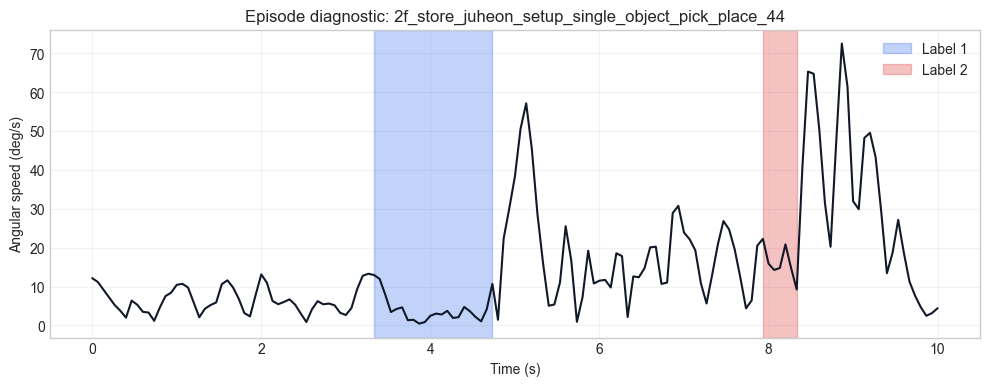

In [82]:
EPISODE_TO_INSPECT = "2f_store_juheon_setup_single_object_pick_place_44"

episode_df = frames_df[frames_df["episode"] == EPISODE_TO_INSPECT].copy()
if episode_df.empty:
    raise ValueError(f"Episode not found: {EPISODE_TO_INSPECT}")

episode_segments = segment_df[segment_df["episode"] == EPISODE_TO_INSPECT].copy()
if episode_segments.empty:
    raise ValueError(f"No labeled segments found for episode: {EPISODE_TO_INSPECT}")

display(episode_segments.round(3))

fps = float(episode_df["fps"].iloc[0])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(episode_df["time_sec"], episode_df["angular_speed_deg_s"], color="#111827", linewidth=1.5)

for _, row in episode_segments.iterrows():
    label_id = int(row["ordered_label_id"])
    ax.axvspan(
        row["start_sec"],
        row["end_sec"] + (1.0 / fps),
        color=ORDERED_LABEL_COLORS.get(label_id, "#9ca3af"),
        alpha=0.28,
        label=f"Label {label_id}",
    )

handles, labels = ax.get_legend_handles_labels()
dedup = dict(zip(labels, handles))
ax.legend(dedup.values(), dedup.keys(), loc="upper right")
ax.set_title(f"Episode diagnostic: {EPISODE_TO_INSPECT}")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular speed (deg/s)")
ax.grid(alpha=0.25)
plt.show()


---

## Batch Result Summary


# Multi-Segment Batch Summary

This notebook summarizes batched `eval_vlm_multisegment.py` results for one model.

It builds:
- a long-form config summary table
- `fps x caption x gaze` matrix tables for hit rate and core VLM metrics
- optional representative-frame tables when `refined_result_multiseg_*.json` files exist


In [83]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RESULTS_DIR = Path("results")
MODEL_NAME = "gemini-3.1-flash-lite-preview"


In [84]:
def load_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    return json.loads(path.read_text())


def collect_result_paths(results_dir: Path, model_name: str) -> list[Path]:
    paths = sorted(results_dir.glob("result_multiseg_*.json"))
    filtered = []
    for path in paths:
        payload = load_json(path)
        if not isinstance(payload, dict):
            continue
        config = payload.get("config") or {}
        if config.get("model") == model_name:
            filtered.append(path)
    return filtered


def get_nested(data: dict, *keys, default=None):
    cur = data
    for key in keys:
        if not isinstance(cur, dict):
            return default
        cur = cur.get(key)
    return default if cur is None else cur


def load_summary_rows(results_dir: Path, model_name: str) -> list[dict]:
    rows = []
    for result_path in collect_result_paths(results_dir, model_name):
        payload = load_json(result_path)
        if payload is None:
            continue

        config = payload.get("config") or {}
        agg = payload.get("aggregate") or {}

        row = {
            "file": result_path.name,
            "fps": int(config.get("video_fps")),
            "caption": bool(config.get("caption")),
            "gaze_annot": bool(config.get("gaze_annot")),
            "num_episodes": get_nested(agg, "num_episodes"),
            "num_success": get_nested(agg, "num_success"),
            "count_acc": get_nested(agg, "exact_count_accuracy", "rate"),
            "all_gt_matched": get_nested(agg, "all_gt_matched_rate", "rate"),
            "all_pred_matched": get_nested(agg, "all_pred_matched_rate", "rate"),
            "seg_f1": get_nested(agg, "segment_f1", "mean"),
            "frame_iou": get_nested(agg, "frame_iou", "mean"),
            "pred_mid_hit": get_nested(agg, "pred_midpoint_hit_rate", "mean"),
            "pred_mid_nearest": get_nested(agg, "pred_midpoint_nearest_dist_mean", "mean"),
        }

        refined_path = results_dir / f"refined_{result_path.name}"
        refined_payload = load_json(refined_path)
        refined_agg = refined_payload.get("aggregate") if isinstance(refined_payload, dict) else {}
        row.update(
            {
                "refined_file": refined_path.name if refined_path.exists() else "",
                "mid_exact": get_nested(refined_agg, "midpoint", "exact_accuracy"),
                "gaze_exact": get_nested(refined_agg, "gaze_velocity", "exact_accuracy"),
                "mid_hit_at_1": get_nested(refined_agg, "midpoint", "hit@1_rate"),
                "gaze_hit_at_1": get_nested(refined_agg, "gaze_velocity", "hit@1_rate"),
                "mid_all_ep": get_nested(refined_agg, "midpoint", "all_interval_episode_rate"),
                "gaze_all_ep": get_nested(refined_agg, "gaze_velocity", "all_interval_episode_rate"),
                "mid_ord_gt": get_nested(refined_agg, "midpoint", "ordered_gt_hit_recall"),
                "gaze_ord_gt": get_nested(refined_agg, "gaze_velocity", "ordered_gt_hit_recall"),
            }
        )
        rows.append(row)
    return rows


In [85]:
summary_df = pd.DataFrame(load_summary_rows(RESULTS_DIR, MODEL_NAME)).sort_values(
    ["fps", "caption", "gaze_annot"]
).reset_index(drop=True)

if summary_df.empty:
    raise ValueError(f"No result_multiseg files found for model={MODEL_NAME}")

summary_df["caption_label"] = summary_df["caption"].map({False: "w/o live caption", True: "w/ live caption"})
summary_df["gaze_label"] = summary_df["gaze_annot"].map({False: "w/o gaze annotation", True: "w/ gaze annotation"})

display(Markdown(f"## Raw Config Summary: `{MODEL_NAME}`"))
display(
    summary_df[
        [
            "fps",
            "caption",
            "gaze_annot",
            "count_acc",
            "all_gt_matched",
            "all_pred_matched",
            "seg_f1",
            "frame_iou",
            "pred_mid_hit",
            "pred_mid_nearest",
            "file",
            "refined_file",
        ]
    ].round(4)
)


## Raw Config Summary: `gemini-3.1-flash-lite-preview`

,fps,caption,gaze_annot,count_acc,all_gt_matched,all_pred_matched,seg_f1,frame_iou,pred_mid_hit,pred_mid_nearest,file,refined_file
0,2,False,False,0.8493,0.7534,0.8630,0.8858,0.3710,0.5479,3.5342,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
1,2,False,True,0.7222,0.5972,0.8056,0.8032,0.2940,0.3819,7.0069,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
2,2,True,False,0.9155,0.8873,0.9437,0.9507,0.3743,0.5000,2.4014,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
3,2,True,True,0.7671,0.6986,0.8630,0.8402,0.3298,0.4863,6.1986,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
4,4,False,False,0.9178,0.7260,0.7808,0.8630,0.3709,0.5959,4.5822,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
5,4,False,True,0.8028,0.5915,0.7183,0.7653,0.2990,0.3873,10.1761,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
6,4,True,False,0.9403,0.8806,0.8955,0.9030,0.3895,0.5970,5.3582,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...
7,4,True,True,0.9041,0.7945,0.8493,0.8836,0.3247,0.4384,4.5753,result_multiseg_gemini-3.1-flash-lite-preview_...,refined_result_multiseg_gemini-3.1-flash-lite-...


In [86]:
ROW_ORDER = ["w/o live caption", "w/ live caption"]
COL_ORDER = ["w/o gaze annotation", "w/ gaze annotation"]


def build_metric_matrix(df: pd.DataFrame, fps: int, metric: str) -> pd.DataFrame:
    subset = df[df["fps"] == fps].copy()
    matrix = subset.pivot(index="caption_label", columns="gaze_label", values=metric)
    matrix = matrix.reindex(index=ROW_ORDER, columns=COL_ORDER)
    return matrix


def display_metric_tables(df: pd.DataFrame, metric: str, title: str, percent: bool = True, digits: int = 1) -> None:
    display(Markdown(f"## {title}"))
    for fps in sorted(df["fps"].dropna().unique()):
        matrix = build_metric_matrix(df, int(fps), metric)
        style = matrix.style
        if percent:
            style = style.format(lambda value: "-" if pd.isna(value) else f"{value * 100:.1f}%")
        else:
            style = style.format(lambda value: "-" if pd.isna(value) else f"{value:.{digits}f}")
        style = style.set_caption(f"fps = {int(fps)}").highlight_max(axis=None, color="#dff6dd")
        display(style)


In [87]:
display_metric_tables(summary_df, "pred_mid_hit", f"VLM: {MODEL_NAME} / midpoint hit rate", percent=True)
display_metric_tables(summary_df, "count_acc", "VLM / exact count match", percent=True)
display_metric_tables(summary_df, "seg_f1", "VLM / segment F1", percent=False, digits=3)
display_metric_tables(summary_df, "frame_iou", "VLM / frame IoU", percent=False, digits=3)


## VLM: gemini-3.1-flash-lite-preview / midpoint hit rate

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,54.8%,38.2%
w/ live caption,50.0%,48.6%


gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,59.6%,38.7%
w/ live caption,59.7%,43.8%


## VLM / exact count match

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,84.9%,72.2%
w/ live caption,91.5%,76.7%


...

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,0.886,0.803
w/ live caption,0.951,0.840


gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,0.863,0.765
w/ live caption,0.903,0.884


## VLM / frame IoU

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,0.371,0.294
w/ live caption,0.374,0.330


gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,0.371,0.299
w/ live caption,0.390,0.325


In [88]:
refined_df = summary_df[summary_df["mid_exact"].notna() | summary_df["gaze_exact"].notna()].copy()

if refined_df.empty:
    display(Markdown("## Representative Frame Tables\nNo `refined_result_multiseg_*.json` files were found for this model."))
else:
    display_metric_tables(refined_df, "mid_exact", f"Representative frame: {MODEL_NAME} / midpoint exact hit", percent=True)
    display_metric_tables(refined_df, "gaze_exact", f"Representative frame: {MODEL_NAME} / min gaze-speed exact hit", percent=True)
    display_metric_tables(refined_df, "mid_all_ep", "Representative frame / midpoint all-interval episode hit", percent=True)
    display_metric_tables(refined_df, "gaze_all_ep", "Representative frame / min gaze-speed all-interval episode hit", percent=True)


## Representative frame: gemini-3.1-flash-lite-preview / midpoint exact hit

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,58.8%,40.8%
w/ live caption,54.0%,53.8%


gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,61.0%,41.9%
w/ live caption,61.8%,48.6%


## Representative frame: gemini-3.1-flash-lite-preview / min gaze-speed exact hit

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,44.1%,36.8%
w/ live caption,48.9%,46.2%


...

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,41.1%,22.2%
w/ live caption,29.6%,37.0%


gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,41.1%,23.9%
w/ live caption,38.8%,21.9%


## Representative frame / min gaze-speed all-interval episode hit

gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,24.7%,19.4%
w/ live caption,25.4%,24.7%


gaze_label,w/o gaze annotation,w/ gaze annotation
caption_label,,
w/o live caption,20.5%,14.1%
w/ live caption,22.4%,19.2%


In [89]:
output_dir = Path("debug/multiseg_summary")
output_dir.mkdir(parents=True, exist_ok=True)

summary_csv_path = output_dir / f"{MODEL_NAME}_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)

for metric_name in ["pred_mid_hit", "count_acc", "seg_f1", "frame_iou"]:
    for fps in sorted(summary_df["fps"].dropna().unique()):
        matrix = build_metric_matrix(summary_df, int(fps), metric_name)
        matrix.to_csv(output_dir / f"{MODEL_NAME}_{metric_name}_fps{int(fps)}.csv")

print(f"Saved summary CSV to: {summary_csv_path}")
print(f"Saved matrix CSV files under: {output_dir}")


Saved summary CSV to: debug/multiseg_summary/gemini-3.1-flash-lite-preview_summary.csv
Saved matrix CSV files under: debug/multiseg_summary


---

## Savitzky-Golay Sweep


# Multi-Segment Savitzky-Golay Sweep

This notebook analyzes representative-frame performance for the `w/ live caption + w/o gaze annotation` multi-segment setting.

It loads a precomputed `window/poly` sweep and shows:
- raw sweep rows
- `window x poly` metric tables for `fps=2` and `fps=4`
- heatmaps for exact hit and related metrics
- top-performing parameter combinations

`window=1, poly=0` is the no-smoothing baseline.

In [90]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

try:
    import seaborn as sns
except ModuleNotFoundError:
    sns = None

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
if sns is not None:
    sns.set_theme(style="whitegrid")
else:
    plt.style.use("default")
    display(Markdown("`seaborn` is not installed, so this section will use a matplotlib heatmap fallback."))

CSV_PATH = Path("debug/gaze_savgol_sweep/gemini-3.1-flash-lite-preview_cap_true_gaze_false_savgol_sweep.csv")
MODEL_NAME = "gemini-3.1-flash-lite-preview"
CONFIG_LABEL = "w/ live caption + w/o gaze annotation"
REQUIRED_SWEEP_COLUMNS = [
    "fps",
    "window",
    "poly",
    "gaze_exact",
    "gaze_hit_at_1",
    "gaze_all_interval_episode",
    "gaze_ordered_gt_recall",
]


`seaborn` is not installed, so this section will use a matplotlib heatmap fallback.

In [91]:
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Sweep CSV not found: {CSV_PATH}")

sweep_df = pd.read_csv(CSV_PATH)
missing_columns = [column for column in REQUIRED_SWEEP_COLUMNS if column not in sweep_df.columns]
if missing_columns:
    raise ValueError(
        "Sweep CSV does not have the expected columns. "
        f"Missing: {missing_columns}. Actual columns: {sweep_df.columns.tolist()}"
    )

sweep_df = sweep_df.sort_values(["fps", "window", "poly"]).reset_index(drop=True)
display(Markdown(f"## Sweep Rows: `{MODEL_NAME}` / {CONFIG_LABEL}"))
display(sweep_df)


## Sweep Rows: `gemini-3.1-flash-lite-preview` / w/ live caption + w/o gaze annotation

,result_file,fps,caption,gaze_annot,window,poly,mid_exact,gaze_exact,mid_hit_at_1,gaze_hit_at_1,mid_all_interval_episode,gaze_all_interval_episode,mid_ordered_gt_recall,gaze_ordered_gt_recall,mid_mean_dist,gaze_mean_dist,num_evaluated_episodes,num_evaluated_intervals,snapshot_file
0,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,1,0,0.5401,0.4672,0.6204,0.5912,0.2958,0.2254,0.5248,0.4539,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
1,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,3,0,0.5401,0.4599,0.6204,0.5328,0.2958,0.2254,0.5248,0.4468,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
2,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,3,1,0.5401,0.4599,0.6204,0.5328,0.2958,0.2254,0.5248,0.4468,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
3,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,3,2,0.5401,0.4672,0.6204,0.5912,0.2958,0.2254,0.5248,0.4539,2.23,2.93,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
4,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,0,0.5401,0.4818,0.6204,0.5182,0.2958,0.2254,0.5248,0.4539,2.23,3.15,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
5,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,1,0.5401,0.4818,0.6204,0.5182,0.2958,0.2254,0.5248,0.4539,2.23,3.15,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
6,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,2,0.5401,0.4526,0.6204,0.5255,0.2958,0.2254,0.5248,0.4326,2.23,3.57,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
7,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,5,3,0.5401,0.4526,0.6204,0.5255,0.2958,0.2254,0.5248,0.4326,2.23,3.57,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
8,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,7,0,0.5401,0.4599,0.6204,0.5255,0.2958,0.2113,0.5248,0.4326,2.23,3.17,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...
9,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,7,1,0.5401,0.4599,0.6204,0.5255,0.2958,0.2113,0.5248,0.4326,2.23,3.17,71,137,result_multiseg_gemini-3.1-flash-lite-preview_...


In [92]:
WINDOW_ORDER = sorted(sweep_df["window"].unique())
POLY_ORDER = sorted(sweep_df["poly"].unique())

METRICS = {
    "gaze_exact": "Min gaze-speed exact hit",
    "gaze_hit_at_1": "Min gaze-speed hit@1",
    "gaze_all_interval_episode": "Min gaze-speed all-interval episode hit",
    "gaze_ordered_gt_recall": "Min gaze-speed ordered GT recall",
}

def build_metric_matrix(df: pd.DataFrame, fps: int, metric: str) -> pd.DataFrame:
    subset = df[df["fps"] == fps].copy()
    matrix = subset.pivot(index="window", columns="poly", values=metric)
    matrix = matrix.reindex(index=WINDOW_ORDER, columns=POLY_ORDER)
    return matrix

def display_metric_table(df: pd.DataFrame, fps: int, metric: str, percent: bool = True, digits: int = 1):
    matrix = build_metric_matrix(df, fps, metric)
    formatted = matrix.copy()
    if percent:
        formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)
        display(formatted.style.format(lambda value: "-" if pd.isna(value) else f"{value:.1f}%").set_caption(f"fps={fps} / {METRICS[metric]}").highlight_max(axis=None, color="#dff6dd"))
    else:
        display(formatted.style.format(lambda value: "-" if pd.isna(value) else f"{value:.{digits}f}").set_caption(f"fps={fps} / {METRICS[metric]}").highlight_max(axis=None, color="#dff6dd"))

def draw_heatmap_fallback(ax, matrix: pd.DataFrame, plot_data: pd.DataFrame, suffix: str) -> None:
    masked = np.ma.masked_invalid(plot_data.to_numpy(dtype=float))
    image = ax.imshow(masked, aspect="auto", cmap="YlGnBu")
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(np.arange(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(np.arange(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    for row_idx, window in enumerate(matrix.index):
        for col_idx, poly in enumerate(matrix.columns):
            value = plot_data.loc[window, poly]
            if pd.notna(value):
                ax.text(col_idx, row_idx, f"{value:.1f}{suffix}", ha="center", va="center", color="#111827", fontsize=10)

def plot_metric_heatmaps(df: pd.DataFrame, metric: str, percent: bool = True):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    fig.suptitle(f"{METRICS[metric]} by Savitzky-Golay window/poly", fontsize=16, fontweight="bold")
    for ax, fps in zip(axes, sorted(df["fps"].unique())):
        matrix = build_metric_matrix(df, int(fps), metric)
        plot_data = matrix * 100.0 if percent else matrix
        suffix = "%" if percent else ""
        if sns is not None:
            sns.heatmap(plot_data, annot=True, fmt=".1f", cmap="YlGnBu", cbar=True, linewidths=0.5, linecolor="#f3f4f6", ax=ax, mask=matrix.isna())
            for text in ax.texts:
                try:
                    value = float(text.get_text())
                except ValueError:
                    continue
                text.set_text(f"{value:.1f}{suffix}")
        else:
            draw_heatmap_fallback(ax, matrix, plot_data, suffix)
        ax.set_title(f"fps = {fps}")
        ax.set_xlabel("Polynomial Order")
        ax.set_ylabel("Window Length")
    plt.show()

def show_top_configs(df: pd.DataFrame, fps: int, metric: str, top_k: int = 8):
    subset = df[df["fps"] == fps].sort_values([metric, "gaze_hit_at_1", "gaze_all_interval_episode"], ascending=False).head(top_k)
    cols = ["window", "poly", metric, "gaze_hit_at_1", "gaze_all_interval_episode", "gaze_ordered_gt_recall", "gaze_mean_dist"]
    display(Markdown(f"### fps = {fps} / Top {top_k} configs by {METRICS[metric]}"))
    display(subset[cols].rename(columns={metric: METRICS[metric]}).style.format({
        METRICS[metric]: lambda value: f"{value * 100:.1f}%",
        "gaze_hit_at_1": lambda value: f"{value * 100:.1f}%",
        "gaze_all_interval_episode": lambda value: f"{value * 100:.1f}%",
        "gaze_ordered_gt_recall": lambda value: f"{value * 100:.1f}%",
        "gaze_mean_dist": lambda value: f"{value:.2f}",
    }).highlight_max(subset=[METRICS[metric]], color="#dff6dd"))


## Exact Hit Tables

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,46.7%,-,-,-
3,46.0%,46.0%,46.7%,-
5,48.2%,48.2%,45.3%,45.3%
7,46.0%,46.0%,45.3%,45.3%
9,45.3%,45.3%,48.9%,48.9%
11,40.2%,40.2%,48.9%,48.9%
15,36.5%,36.5%,45.3%,45.3%
21,41.6%,41.6%,41.6%,41.6%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,45.8%,-,-,-
3,48.1%,48.1%,45.8%,-
5,44.3%,44.3%,45.0%,45.0%
7,44.3%,44.3%,49.6%,49.6%
9,45.8%,45.8%,43.5%,43.5%
11,36.6%,36.6%,44.3%,44.3%
15,42.8%,42.8%,44.3%,44.3%
21,42.0%,42.0%,45.0%,45.0%


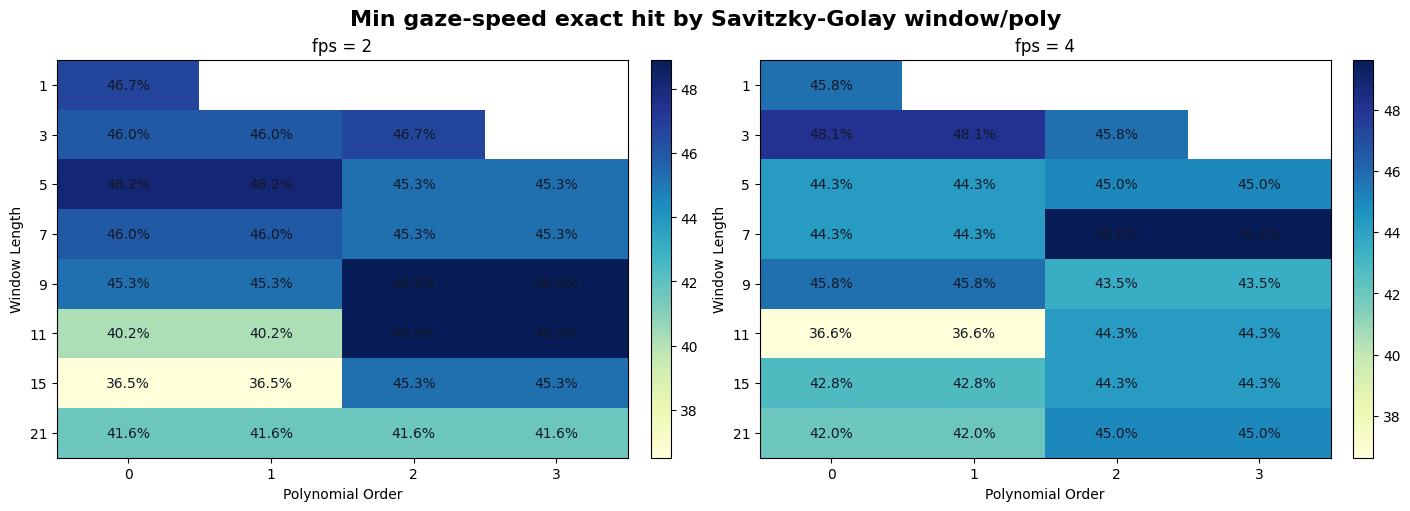

In [93]:
display(Markdown("## Exact Hit Tables"))
for fps in sorted(sweep_df["fps"].unique()):
    display_metric_table(sweep_df, int(fps), "gaze_exact", percent=True)

plot_metric_heatmaps(sweep_df, "gaze_exact", percent=True)


## Additional Metrics

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,59.1%,-,-,-
3,53.3%,53.3%,59.1%,-
5,51.8%,51.8%,52.5%,52.5%
7,52.5%,52.5%,50.4%,50.4%
9,51.1%,51.1%,53.3%,53.3%
11,53.3%,53.3%,54.0%,54.0%
15,43.1%,43.1%,52.5%,52.5%
21,49.6%,50.4%,51.1%,51.1%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,58.0%,-,-,-
3,55.7%,55.7%,58.0%,-
5,53.4%,53.4%,53.4%,53.4%
7,51.1%,51.1%,55.7%,55.7%
9,54.2%,54.2%,51.9%,51.9%
11,51.9%,51.9%,51.9%,51.9%
15,48.9%,48.9%,51.9%,51.9%
21,48.9%,48.9%,55.7%,55.7%


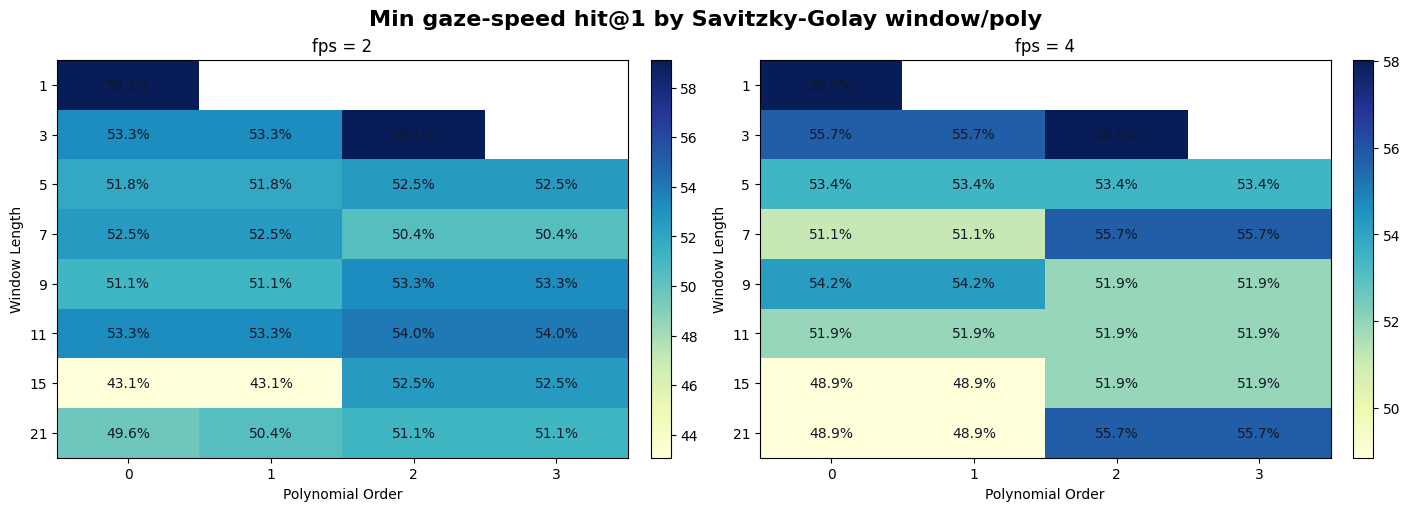

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,22.5%,-,-,-
3,22.5%,22.5%,22.5%,-
5,22.5%,22.5%,22.5%,22.5%
7,21.1%,21.1%,23.9%,23.9%
9,22.5%,22.5%,23.9%,23.9%
11,16.9%,16.9%,25.4%,25.4%
15,18.3%,18.3%,21.1%,21.1%
21,18.3%,18.3%,18.3%,18.3%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,20.9%,-,-,-
3,23.9%,23.9%,20.9%,-
5,22.4%,22.4%,23.9%,23.9%
7,20.9%,20.9%,28.4%,28.4%
9,19.4%,19.4%,23.9%,23.9%
11,13.4%,13.4%,22.4%,22.4%
15,20.9%,20.9%,19.4%,19.4%
21,22.4%,22.4%,23.9%,23.9%


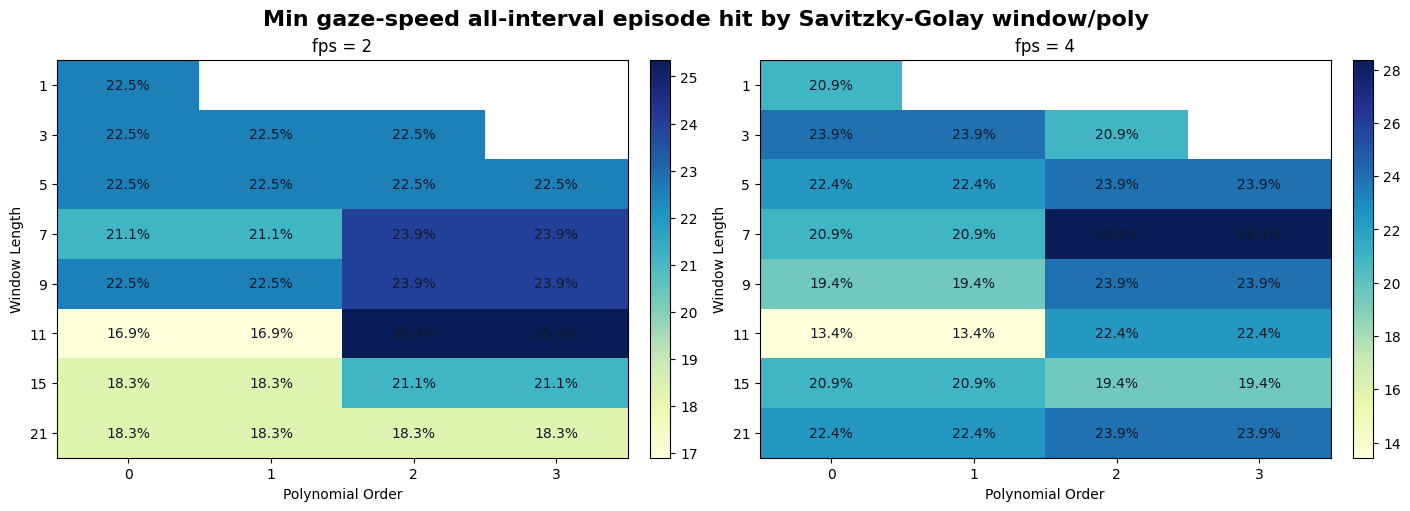

/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,45.4%,-,-,-
3,44.7%,44.7%,45.4%,-
5,45.4%,45.4%,43.3%,43.3%
7,43.3%,43.3%,44.0%,44.0%
9,41.8%,41.8%,46.1%,46.1%
11,36.2%,36.2%,46.8%,46.8%
15,34.8%,34.8%,41.8%,41.8%
21,39.7%,39.7%,39.0%,39.0%


/var/folders/hf/yzxm_1_j2gn4n9605z4cznc00000gn/T/ipykernel_68715/3862677674.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  formatted = formatted.applymap(lambda value: np.nan if pd.isna(value) else value * 100.0)


poly,0,1,2,3
window,,,,
1,45.1%,-,-,-
3,47.4%,47.4%,45.1%,-
5,42.9%,42.9%,44.4%,44.4%
7,43.6%,43.6%,48.9%,48.9%
9,45.1%,45.1%,42.1%,42.1%
11,36.1%,36.1%,43.6%,43.6%
15,42.1%,42.1%,42.9%,42.9%
21,40.6%,40.6%,44.4%,44.4%


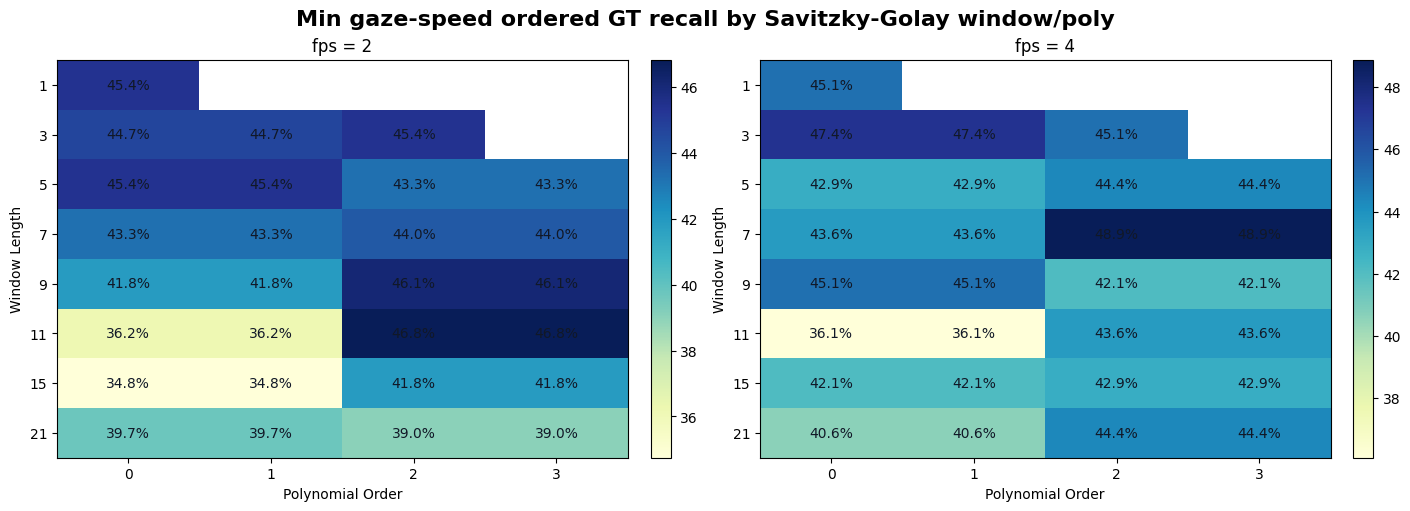

In [94]:
display(Markdown("## Additional Metrics"))
for metric in ["gaze_hit_at_1", "gaze_all_interval_episode", "gaze_ordered_gt_recall"]:
    for fps in sorted(sweep_df["fps"].unique()):
        display_metric_table(sweep_df, int(fps), metric, percent=True)
    plot_metric_heatmaps(sweep_df, metric, percent=True)


In [95]:
display(Markdown("## Best Configs"))
for fps in sorted(sweep_df["fps"].unique()):
    show_top_configs(sweep_df, int(fps), "gaze_exact", top_k=10)


## Best Configs

### fps = 2 / Top 10 configs by Min gaze-speed exact hit

,window,poly,Min gaze-speed exact hit,gaze_hit_at_1,gaze_all_interval_episode,gaze_ordered_gt_recall,gaze_mean_dist
18,11,2,48.9%,54.0%,25.4%,46.8%,3.22
19,11,3,48.9%,54.0%,25.4%,46.8%,3.22
14,9,2,48.9%,53.3%,23.9%,46.1%,3.26
15,9,3,48.9%,53.3%,23.9%,46.1%,3.26
4,5,0,48.2%,51.8%,22.5%,45.4%,3.15
5,5,1,48.2%,51.8%,22.5%,45.4%,3.15
0,1,0,46.7%,59.1%,22.5%,45.4%,2.93
3,3,2,46.7%,59.1%,22.5%,45.4%,2.93
1,3,0,46.0%,53.3%,22.5%,44.7%,2.93
2,3,1,46.0%,53.3%,22.5%,44.7%,2.93


### fps = 4 / Top 10 configs by Min gaze-speed exact hit

,window,poly,Min gaze-speed exact hit,gaze_hit_at_1,gaze_all_interval_episode,gaze_ordered_gt_recall,gaze_mean_dist
38,7,2,49.6%,55.7%,28.4%,48.9%,6.05
39,7,3,49.6%,55.7%,28.4%,48.9%,6.05
29,3,0,48.1%,55.7%,23.9%,47.4%,6.10
30,3,1,48.1%,55.7%,23.9%,47.4%,6.09
28,1,0,45.8%,58.0%,20.9%,45.1%,5.95
31,3,2,45.8%,58.0%,20.9%,45.1%,5.95
40,9,0,45.8%,54.2%,19.4%,45.1%,6.29
41,9,1,45.8%,54.2%,19.4%,45.1%,6.26
54,21,2,45.0%,55.7%,23.9%,44.4%,6.09
55,21,3,45.0%,55.7%,23.9%,44.4%,6.11


In [96]:
output_dir = Path("debug/gaze_savgol_sweep")
for fps in sorted(sweep_df["fps"].unique()):
    matrix = build_metric_matrix(sweep_df, int(fps), "gaze_exact")
    matrix.to_csv(output_dir / f"gemini-3.1-flash-lite-preview_cap_true_gaze_false_gaze_exact_fps{int(fps)}.csv")
print(f"Saved per-fps exact-hit matrices under: {output_dir}")


Saved per-fps exact-hit matrices under: debug/gaze_savgol_sweep


---

## Representative Frame Methods


# Representative Frame Method Comparison

This notebook compares representative-frame selection rules for the `w/ live caption + w/o gaze annotation` multi-segment setting.

Methods included:
- `midpoint`
- `min_velocity`
- `local_avg_center`
- `hybrid_mid_gaze`
- `plateau_center`
- `equal_bin`

Current defaults:
- Savitzky-Golay: `window=11`, `poly=2`
- local average radius: `2`
- center fraction: `0.6`
- hybrid lambda: `0.75`
- plateau quantile: `0.25`
- equal-bin count: `5`

In [97]:
from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

CSV_PATH = Path("debug/repframe_methods/repframe_methods_cap_true_gaze_false.csv")
if not CSV_PATH.exists():
    raise FileNotFoundError(f"Missing CSV: {CSV_PATH}")

df = pd.read_csv(CSV_PATH).sort_values(["fps", "method"]).reset_index(drop=True)
display(df)


,method,num_evaluated_episodes,num_evaluated_intervals,exact_hit_rate,any_hit_episode_rate,all_interval_episode_rate,ordered_gt_hit_recall,ordered_all_hit_episode_rate,mean_nearest_gt_dist,hit@0_rate,hit@1_rate,hit@3_rate,hit@5_rate,result_file,fps,caption,gaze_annot,model
0,equal_bin,71,137,0.4599,0.6338,0.2676,0.4397,0.2535,3.09,0.4599,0.5182,0.7007,0.8175,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,gemini-3.1-flash-lite-preview
1,hybrid_mid_gaze,71,137,0.4964,0.6761,0.2958,0.4752,0.2817,2.96,0.4964,0.5620,0.7080,0.8175,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,gemini-3.1-flash-lite-preview
2,local_avg_center,71,137,0.5620,0.7324,0.3662,0.5390,0.3521,2.55,0.5620,0.5985,0.7299,0.8540,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,gemini-3.1-flash-lite-preview
3,midpoint,71,137,0.5401,0.7465,0.2958,0.5248,0.2958,2.23,0.5401,0.6204,0.8029,0.8467,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,gemini-3.1-flash-lite-preview
4,min_velocity,71,137,0.4891,0.7183,0.2535,0.4681,0.2254,3.22,0.4891,0.5401,0.7518,0.8175,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,gemini-3.1-flash-lite-preview
5,plateau_center,71,137,0.4672,0.6761,0.2535,0.4397,0.2254,2.88,0.4672,0.5620,0.7226,0.8394,result_multiseg_gemini-3.1-flash-lite-preview_...,2,True,False,gemini-3.1-flash-lite-preview
6,equal_bin,67,131,0.4122,0.5970,0.2090,0.4060,0.2090,6.38,0.4122,0.5191,0.7176,0.8015,result_multiseg_gemini-3.1-flash-lite-preview_...,4,True,False,gemini-3.1-flash-lite-preview
7,hybrid_mid_gaze,67,131,0.4733,0.6866,0.2537,0.4586,0.2388,6.24,0.4733,0.5191,0.6947,0.8015,result_multiseg_gemini-3.1-flash-lite-preview_...,4,True,False,gemini-3.1-flash-lite-preview
8,local_avg_center,67,131,0.5267,0.7612,0.2836,0.5113,0.2687,5.51,0.5267,0.6031,0.7786,0.8779,result_multiseg_gemini-3.1-flash-lite-preview_...,4,True,False,gemini-3.1-flash-lite-preview
9,midpoint,67,131,0.6183,0.8507,0.3881,0.6015,0.3582,5.26,0.6183,0.6870,0.8092,0.8550,result_multiseg_gemini-3.1-flash-lite-preview_...,4,True,False,gemini-3.1-flash-lite-preview


In [98]:
METHOD_ORDER = [
    "midpoint",
    "min_velocity",
    "local_avg_center",
    "hybrid_mid_gaze",
    "plateau_center",
    "equal_bin",
]

METHOD_LABELS = {
    "midpoint": "Midpoint",
    "min_velocity": "Min Velocity",
    "local_avg_center": "Local Avg + Center",
    "hybrid_mid_gaze": "Hybrid Mid+Gaze",
    "plateau_center": "Plateau Center",
    "equal_bin": "Equal Bin",
}

def method_metric_table(metric: str) -> pd.DataFrame:
    table = df.pivot(index="method", columns="fps", values=metric)
    table = table.reindex(METHOD_ORDER)
    table.index = [METHOD_LABELS[name] for name in table.index]
    return table

def display_percent_table(metric: str, title: str):
    table = method_metric_table(metric)
    display(Markdown(f"## {title}"))
    display(table.style.format(lambda value: f"{value * 100:.1f}%").highlight_max(axis=0, color="#dff6dd"))


In [99]:
display_percent_table("exact_hit_rate", "Interval Exact Hit Rate")
display_percent_table("hit@1_rate", "Interval Hit@1 Rate")
display_percent_table("all_interval_episode_rate", "Episode All-Interval Hit Rate")
display_percent_table("ordered_gt_hit_recall", "Ordered GT Hit Recall")


## Interval Exact Hit Rate

fps,2,4
Midpoint,54.0%,61.8%
Min Velocity,48.9%,44.3%
Local Avg + Center,56.2%,52.7%
Hybrid Mid+Gaze,49.6%,47.3%
Plateau Center,46.7%,43.5%
Equal Bin,46.0%,41.2%


## Interval Hit@1 Rate

fps,2,4
Midpoint,62.0%,68.7%
Min Velocity,54.0%,51.9%
Local Avg + Center,59.9%,60.3%
Hybrid Mid+Gaze,56.2%,51.9%
Plateau Center,56.2%,54.2%
Equal Bin,51.8%,51.9%


## Episode All-Interval Hit Rate

fps,2,4
Midpoint,29.6%,38.8%
Min Velocity,25.4%,22.4%
Local Avg + Center,36.6%,28.4%
Hybrid Mid+Gaze,29.6%,25.4%
Plateau Center,25.4%,19.4%
Equal Bin,26.8%,20.9%


## Ordered GT Hit Recall

fps,2,4
Midpoint,52.5%,60.2%
Min Velocity,46.8%,43.6%
Local Avg + Center,53.9%,51.1%
Hybrid Mid+Gaze,47.5%,45.9%
Plateau Center,44.0%,42.1%
Equal Bin,44.0%,40.6%


In [100]:
summary_cols = [
    "method",
    "fps",
    "exact_hit_rate",
    "hit@1_rate",
    "all_interval_episode_rate",
    "ordered_gt_hit_recall",
    "mean_nearest_gt_dist",
]

summary_df = df[summary_cols].copy()
summary_df["method"] = summary_df["method"].map(METHOD_LABELS)
display(Markdown("## Compact Summary"))
display(summary_df.style.format({
    "exact_hit_rate": lambda value: f"{value * 100:.1f}%",
    "hit@1_rate": lambda value: f"{value * 100:.1f}%",
    "all_interval_episode_rate": lambda value: f"{value * 100:.1f}%",
    "ordered_gt_hit_recall": lambda value: f"{value * 100:.1f}%",
    "mean_nearest_gt_dist": lambda value: f"{value:.2f}",
}))


## Compact Summary

,method,fps,exact_hit_rate,hit@1_rate,all_interval_episode_rate,ordered_gt_hit_recall,mean_nearest_gt_dist
0,Equal Bin,2,46.0%,51.8%,26.8%,44.0%,3.09
1,Hybrid Mid+Gaze,2,49.6%,56.2%,29.6%,47.5%,2.96
2,Local Avg + Center,2,56.2%,59.9%,36.6%,53.9%,2.55
3,Midpoint,2,54.0%,62.0%,29.6%,52.5%,2.23
4,Min Velocity,2,48.9%,54.0%,25.4%,46.8%,3.22
5,Plateau Center,2,46.7%,56.2%,25.4%,44.0%,2.88
6,Equal Bin,4,41.2%,51.9%,20.9%,40.6%,6.38
7,Hybrid Mid+Gaze,4,47.3%,51.9%,25.4%,45.9%,6.24
8,Local Avg + Center,4,52.7%,60.3%,28.4%,51.1%,5.51
9,Midpoint,4,61.8%,68.7%,38.8%,60.2%,5.26


## Interactive Episode Browser

Browse a result file, click an episode, and compare GT vs predicted intervals with gaze-speed overlays, representative-frame markers, and debug clips.


In [101]:
from pathlib import Path
import html
import json
import re
from collections import OrderedDict

import shutil
import subprocess
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import HTML, Video, clear_output, display
from scipy.signal import savgol_filter

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

DATASET_DIR = Path("dataset")
PREDICTION_SOURCE = Path("eval_results_multiseg/multiseg_gemini-3.1-flash-lite-preview_fps4_max2_results.jsonl")
EPISODE_NAME = "2f_store_juheon_setup_double_object_pickup_10"
VIDEO_FPS_FALLBACK = 15.0
FFMPEG_BIN = shutil.which("ffmpeg") or "ffmpeg"

CLIP_PADDING_SEC = 0.4
CLIP_OUTPUT_DIR = Path("debug/generated_multiseg_clips")
DISPLAY_GT_CLIPS = True
DISPLAY_PRED_CLIPS = True

GT_COLORS = {
    1: "#2563eb",
    2: "#ef4444",
    3: "#10b981",
}

PRED_COLORS = {
    1: "#1d4ed8",
    2: "#b91c1c",
    3: "#047857",
}

RESULT_METRIC_KEYS = [
    "pred_interval_count",
    "gt_interval_count",
    "count_error",
    "abs_count_error",
    "matched_count",
    "segment_precision",
    "segment_recall",
    "segment_f1",
    "exact_count_match",
    "all_gt_matched",
    "all_pred_matched",
    "frame_iou",
    "gt_frame_coverage",
    "pred_frame_precision",
    "pred_midpoint_hit_count",
    "pred_midpoint_hit_rate",
    "pred_midpoint_nearest_dist_mean",
    "mean_matched_iou",
    "mean_matched_midpoint_error_sec",
    "best_pred_iou_mean",
    "best_gt_iou_mean",
]


In [102]:
def compute_angular_velocity(pitch_yaw: np.ndarray, fps: float, savgol_window: int = 11, savgol_poly: int = 2) -> np.ndarray:
    pitch = pitch_yaw[:, 0]
    yaw = pitch_yaw[:, 3]

    total_frames = len(pitch)
    if total_frames <= 1 or fps <= 0:
        return np.zeros(total_frames, dtype=np.float64)

    if total_frames < savgol_window:
        savgol_window = total_frames if total_frames % 2 == 1 else total_frames - 1
    savgol_window = max(savgol_window, 3)

    if savgol_poly >= savgol_window:
        savgol_poly = savgol_window - 1

    pitch_s = savgol_filter(pitch, savgol_window, savgol_poly)
    yaw_s = savgol_filter(yaw, savgol_window, savgol_poly)

    x = np.cos(pitch_s) * np.cos(yaw_s)
    y = np.cos(pitch_s) * np.sin(yaw_s)
    z = np.sin(pitch_s)

    step_dot = np.clip(
        x[:-1] * x[1:] + y[:-1] * y[1:] + z[:-1] * z[1:],
        -1.0,
        1.0,
    )
    step_velocity = np.arccos(step_dot) * fps

    angular_velocity = np.zeros(total_frames, dtype=np.float64)
    angular_velocity[0] = step_velocity[0]
    angular_velocity[-1] = step_velocity[-1]

    if total_frames > 2:
        center_dot = np.clip(
            x[:-2] * x[2:] + y[:-2] * y[2:] + z[:-2] * z[2:],
            -1.0,
            1.0,
        )
        angular_velocity[1:-1] = np.arccos(center_dot) * (fps / 2.0)

    return np.rad2deg(angular_velocity)


def _coerce_int(value):
    try:
        return int(value)
    except (TypeError, ValueError):
        return None


def extract_segments(frame_indices: np.ndarray) -> list[tuple[int, int]]:
    if len(frame_indices) == 0:
        return []

    frame_indices = [int(idx) for idx in frame_indices]
    segments = []
    start = frame_indices[0]
    prev = frame_indices[0]

    for current in frame_indices[1:]:
        if current != prev + 1:
            segments.append((start, prev))
            start = current
        prev = current

    segments.append((start, prev))
    return segments


def extract_segments_from_labels(labels: np.ndarray) -> list[dict]:
    labels = labels.astype(np.int8)
    if labels.size == 0:
        return []

    diffs = np.diff(labels)
    starts = list(np.where(diffs == 1)[0] + 1)
    ends = list(np.where(diffs == -1)[0] + 1)
    if labels[0] == 1:
        starts = [0] + starts
    if labels[-1] == 1:
        ends = ends + [len(labels)]

    segments = []
    for start, end_exclusive in zip(starts, ends):
        end = int(end_exclusive - 1)
        if end >= start:
            segments.append({"start_frame": int(start), "end_frame": end})
    return segments


def load_ordered_segments(episode_dir: Path, labels: np.ndarray | None) -> tuple[list[dict], float | None]:
    ann_path = episode_dir / "annotations.json"
    if ann_path.exists():
        ann_data = json.loads(ann_path.read_text())
        fps = ann_data.get("fps")
        try:
            fps = float(fps)
        except (TypeError, ValueError):
            fps = None

        annotations = ann_data.get("annotations", [])
        if isinstance(annotations, list):
            segments = []
            for ann in annotations:
                if not isinstance(ann, dict):
                    continue
                kind = ann.get("kind")
                if kind not in (None, "label"):
                    continue
                start = _coerce_int(ann.get("start_frame", ann.get("start")))
                end = _coerce_int(ann.get("end_frame", ann.get("end")))
                if start is None or end is None:
                    continue
                if end < start:
                    start, end = end, start
                segments.append({"start_frame": start, "end_frame": end})
            if segments:
                return sorted(segments, key=lambda item: (item["start_frame"], item["end_frame"])), fps

    seg_path = episode_dir / "segments.json"
    if seg_path.exists():
        seg_data = json.loads(seg_path.read_text())
        raw_segments = seg_data.get("segments", [])
        if isinstance(raw_segments, list):
            segments = []
            for seg in raw_segments:
                if not isinstance(seg, dict):
                    continue
                start = _coerce_int(seg.get("start_frame", seg.get("start")))
                end = _coerce_int(seg.get("end_frame", seg.get("end")))
                if start is None or end is None:
                    continue
                if end < start:
                    start, end = end, start
                segments.append({"start_frame": start, "end_frame": end})
            if segments:
                return sorted(segments, key=lambda item: (item["start_frame"], item["end_frame"])), None

    if labels is not None:
        return extract_segments_from_labels(labels), None
    return [], None


def load_episode_data(episode_dir: Path, fps_fallback: float = VIDEO_FPS_FALLBACK) -> dict:
    if not episode_dir.exists():
        raise FileNotFoundError(f"Episode directory not found: {episode_dir}")

    labels_path = episode_dir / "labels.npy"
    gaze_path = episode_dir / "gaze.json"
    video_path = episode_dir / "video.mp4"

    labels = np.load(labels_path).astype(np.int8) if labels_path.exists() else None
    gaze_frames = json.loads(gaze_path.read_text()).get("frames", []) if gaze_path.exists() else []

    ordered_segments, ann_fps = load_ordered_segments(episode_dir, labels)
    fps = ann_fps or fps_fallback

    if labels is None:
        total_frames = len(gaze_frames)
        if total_frames <= 0 and ordered_segments:
            total_frames = max(seg["end_frame"] for seg in ordered_segments) + 1
        labels = np.zeros(total_frames, dtype=np.int8)
        for seg in ordered_segments:
            labels[seg["start_frame"]:seg["end_frame"] + 1] = 1
    else:
        total_frames = len(labels)

    if not ordered_segments:
        ordered_segments = extract_segments_from_labels(labels)

    ordered_segments = sorted(ordered_segments, key=lambda item: (item["start_frame"], item["end_frame"]))
    gt_segments = []
    ordered_label_signal = np.zeros(total_frames, dtype=np.int8)
    for idx, seg in enumerate(ordered_segments):
        start = int(seg["start_frame"])
        end = int(seg["end_frame"])
        ordered_label_signal[start:end + 1] = idx + 1
        mid_frame = int(round((start + end) / 2))
        gt_segments.append(
            {
                "segment_idx": idx,
                "label_id": idx + 1,
                "start_frame": start,
                "end_frame": end,
                "start_sec": round(start / fps, 4),
                "end_sec": round(end / fps, 4),
                "mid_frame": mid_frame,
                "mid_sec": round(mid_frame / fps, 4),
                "duration_frames": end - start + 1,
                "duration_sec": round((end - start + 1) / fps, 4),
            }
        )

    if gaze_frames:
        pitch_yaw = np.array(
            [
                [
                    frame["pitch"],
                    frame["pitch_lower"],
                    frame["pitch_upper"],
                    frame["yaw"],
                    frame["yaw_lower"],
                    frame["yaw_upper"],
                ]
                for frame in gaze_frames[:total_frames]
            ],
            dtype=np.float64,
        )
        angular_speed = compute_angular_velocity(pitch_yaw, fps=fps)
    else:
        angular_speed = np.full(total_frames, np.nan)

    frame_times = np.arange(total_frames, dtype=np.float64) / fps if fps > 0 else np.arange(total_frames, dtype=np.float64)
    return {
        "episode": episode_dir.name,
        "fps": fps,
        "total_frames": total_frames,
        "duration_sec": total_frames / fps if fps > 0 else 0.0,
        "labels": labels,
        "ordered_label_signal": ordered_label_signal,
        "segments": gt_segments,
        "frame_times": frame_times,
        "frame_step_sec": 1.0 / fps if fps > 0 else 1.0,
        "angular_speed_deg_s": angular_speed,
        "video_path": video_path,
    }


def build_prediction_intervals_from_pair_lists(frame_pairs, sec_pairs=None):
    intervals = []
    sec_pairs = sec_pairs or []
    for idx, frame_pair in enumerate(frame_pairs):
        if not isinstance(frame_pair, (list, tuple)) or len(frame_pair) < 2:
            continue
        start_frame = int(frame_pair[0])
        end_frame = int(frame_pair[1])
        if end_frame < start_frame:
            start_frame, end_frame = end_frame, start_frame

        start_sec = None
        end_sec = None
        if idx < len(sec_pairs):
            sec_pair = sec_pairs[idx]
            if isinstance(sec_pair, (list, tuple)) and len(sec_pair) >= 2:
                try:
                    start_sec = float(sec_pair[0])
                    end_sec = float(sec_pair[1])
                except (TypeError, ValueError):
                    start_sec = None
                    end_sec = None

        mid_frame = int(round((start_frame + end_frame) / 2))
        interval = {
            "pred_idx": idx,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "mid_frame": mid_frame,
            "duration_frames": end_frame - start_frame + 1,
        }
        if start_sec is not None and end_sec is not None:
            interval.update(
                {
                    "start_sec": start_sec,
                    "end_sec": end_sec,
                    "mid_sec": round((start_sec + end_sec) / 2.0, 4),
                    "duration_sec": round(end_sec - start_sec, 4),
                }
            )
        intervals.append(interval)
    return intervals


def load_prediction_records(source_path: Path) -> list[dict]:
    if not source_path.exists():
        raise FileNotFoundError(f"Prediction source not found: {source_path}")

    if source_path.suffix == ".jsonl":
        with open(source_path) as f:
            return [json.loads(line) for line in f if line.strip()]

    if source_path.suffix == ".json":
        with open(source_path) as f:
            payload = json.load(f)

        if isinstance(payload, dict) and isinstance(payload.get("episodes"), list):
            records = []
            for item in payload["episodes"]:
                metrics = {key: item.get(key) for key in RESULT_METRIC_KEYS if key in item}
                records.append(
                    {
                        "episode": item["episode"],
                        "prediction": {
                            "reasoning": item.get("prediction_reasoning", ""),
                            "intervals": build_prediction_intervals_from_pair_lists(
                                item.get("predicted_intervals_frames", []),
                                item.get("predicted_intervals_sec", []),
                            ),
                        },
                        "metrics": metrics,
                        "matches": item.get("matches", []),
                    }
                )
            return records

    raise ValueError(f"Unsupported prediction source format: {source_path}")


def normalize_prediction_intervals(intervals: list[dict], fps: float) -> list[dict]:
    normalized = []
    for idx, interval in enumerate(intervals):
        start_frame = int(interval["start_frame"])
        end_frame = int(interval["end_frame"])
        if end_frame < start_frame:
            start_frame, end_frame = end_frame, start_frame

        pred_idx = int(interval.get("pred_idx", idx))
        raw_start_sec = interval.get("start_sec")
        raw_end_sec = interval.get("end_sec")
        if raw_start_sec is not None:
            raw_start_sec = float(raw_start_sec)
        if raw_end_sec is not None:
            raw_end_sec = float(raw_end_sec)

        if fps > 0:
            start_sec = round(start_frame / fps, 4)
            end_sec = round(end_frame / fps, 4)
            midpoint_sec_exact = round(((start_frame + end_frame) / 2.0) / fps, 4)
        else:
            start_sec = float(start_frame)
            end_sec = float(end_frame)
            midpoint_sec_exact = (start_sec + end_sec) / 2.0

        mid_frame = int(np.floor(((start_frame + end_frame) / 2.0) + 0.5))
        normalized.append(
            {
                "pred_idx": pred_idx,
                "start_frame": start_frame,
                "end_frame": end_frame,
                "start_sec": start_sec,
                "end_sec": end_sec,
                "raw_start_sec": raw_start_sec,
                "raw_end_sec": raw_end_sec,
                "mid_frame": mid_frame,
                "mid_sec": midpoint_sec_exact,
                "duration_frames": end_frame - start_frame + 1,
                "duration_sec": round(end_sec - start_sec, 4),
            }
        )

    return sorted(normalized, key=lambda item: (item["pred_idx"], item["start_frame"], item["end_frame"]))


def build_interval_signal(total_frames: int, intervals: list[dict], id_key: str) -> np.ndarray:
    signal = np.zeros(total_frames, dtype=np.int8)
    if total_frames <= 0:
        return signal

    for fallback_idx, interval in enumerate(intervals):
        label_id = int(interval.get(id_key, fallback_idx)) + 1
        start_frame = max(0, min(total_frames - 1, int(interval["start_frame"])))
        end_frame = max(0, min(total_frames - 1, int(interval["end_frame"])))
        if end_frame >= start_frame:
            signal[start_frame:end_frame + 1] = label_id
    return signal


def sanitize_filename(text: str) -> str:
    return re.sub(r"[^A-Za-z0-9._-]+", "_", text)


def extract_video_subclip(video_path: Path, start_sec: float, end_sec: float, output_path: Path, overlay_text: str | None = None) -> Path:
    if end_sec <= start_sec:
        end_sec = start_sec + 0.1

    output_path.parent.mkdir(parents=True, exist_ok=True)
    cmd = [
        FFMPEG_BIN,
        "-y",
        "-ss",
        f"{start_sec:.4f}",
        "-to",
        f"{end_sec:.4f}",
        "-i",
        str(video_path),
        "-an",
        "-c:v",
        "libx264",
        "-pix_fmt",
        "yuv420p",
        str(output_path),
    ]
    try:
        subprocess.run(cmd, check=True, capture_output=True)
    except FileNotFoundError as exc:
        raise RuntimeError("ffmpeg binary not found") from exc
    except subprocess.CalledProcessError as exc:
        stderr = exc.stderr.decode("utf-8", errors="ignore")
        raise RuntimeError(f"ffmpeg failed for {output_path}: {stderr}") from exc
    return output_path


def render_clip_grid(clip_df: pd.DataFrame, columns: int = 2, video_width: int = 360) -> None:
    if clip_df.empty:
        print("No clips to display.")
        return

    cards = []
    for _, row in clip_df.iterrows():
        title = (
            f"{row['kind'].upper()} label {int(row['label_id'])} | "
            f"segment={row['start_sec']:.2f}-{row['end_sec']:.2f}s | "
            f"clip={row['clip_start_sec']:.2f}-{row['clip_end_sec']:.2f}s"
        )
        video_html = Video(
            str(row["clip_path"]),
            embed=False,
            width=video_width,
            html_attributes="controls preload='metadata' style='width:100%;height:auto;display:block;'",
        )._repr_html_()
        cards.append(
            "<div style='border:1px solid #e5e7eb;border-radius:12px;padding:10px;background:#ffffff;'>"
            f"<div style='font-size:12px;font-weight:600;margin-bottom:8px;color:#111827;'>{html.escape(title)}</div>"
            f"{video_html}"
            "</div>"
        )

    grid_html = (
        "<div style='display:grid;grid-template-columns:repeat("
        f"{max(1, columns)}, minmax(0, 1fr));gap:12px;align-items:start;'>"
        + "".join(cards)
        + "</div>"
    )
    display(HTML(grid_html))


def build_clip_specs(episode_data: dict, prediction_intervals: list[dict], include_gt: bool = DISPLAY_GT_CLIPS, include_pred: bool = DISPLAY_PRED_CLIPS) -> pd.DataFrame:
    clip_rows = []
    video_path = episode_data["video_path"]
    total_duration = episode_data["duration_sec"]
    episode_dir = CLIP_OUTPUT_DIR / sanitize_filename(episode_data["episode"])

    if include_gt:
        for segment in episode_data["segments"]:
            label_id = int(segment["label_id"])
            clip_rows.append(
                {
                    "kind": "gt",
                    "label_id": label_id,
                    "start_sec": float(segment["start_sec"]),
                    "end_sec": float(segment["end_sec"] + episode_data["frame_step_sec"]),
                    "start_frame": int(segment["start_frame"]),
                    "end_frame": int(segment["end_frame"]),
                    "duration_sec": float(segment["duration_sec"]),
                    "video_path": video_path,
                    "overlay_text": f"GT {label_id}",
                    "clip_path": episode_dir / f"gt_label_{label_id}.mp4",
                }
            )

    if include_pred:
        for interval in prediction_intervals:
            label_id = int(interval["pred_idx"]) + 1
            clip_rows.append(
                {
                    "kind": "pred",
                    "label_id": label_id,
                    "start_sec": float(interval["start_sec"]),
                    "end_sec": float(interval["end_sec"] + episode_data["frame_step_sec"]),
                    "start_frame": int(interval["start_frame"]),
                    "end_frame": int(interval["end_frame"]),
                    "duration_sec": float(interval["duration_sec"]),
                    "video_path": video_path,
                    "overlay_text": f"Pred {label_id}",
                    "clip_path": episode_dir / f"pred_label_{label_id}.mp4",
                }
            )

    for row in clip_rows:
        row["clip_start_sec"] = max(0.0, row["start_sec"] - CLIP_PADDING_SEC)
        row["clip_end_sec"] = min(total_duration, row["end_sec"] + CLIP_PADDING_SEC)
        extract_video_subclip(
            row["video_path"],
            row["clip_start_sec"],
            row["clip_end_sec"],
            row["clip_path"],
            overlay_text=row["overlay_text"],
        )

    return pd.DataFrame(clip_rows)


In [103]:
prediction_records = load_prediction_records(PREDICTION_SOURCE)
available_episodes = sorted(record["episode"] for record in prediction_records)
print(f"Loaded {len(prediction_records)} prediction record(s) from {PREDICTION_SOURCE}")
print("Available episodes:")
for episode in available_episodes:
    print("  -", episode)

selected_record = next((record for record in prediction_records if record["episode"] == EPISODE_NAME), None)
if selected_record is None:
    raise ValueError(f"Episode not found in prediction source: {EPISODE_NAME}")

episode_data = load_episode_data(DATASET_DIR / EPISODE_NAME)
prediction = selected_record.get("prediction") or {"reasoning": "", "intervals": []}
prediction_intervals = normalize_prediction_intervals(prediction.get("intervals", []), episode_data["fps"])
predicted_signal = build_interval_signal(episode_data["total_frames"], prediction_intervals, id_key="pred_idx")

metrics = selected_record.get("metrics") or {}
matches = selected_record.get("matches") or []
reasoning = prediction.get("reasoning", "")

print(f"Selected episode: {EPISODE_NAME}")
print(f"FPS: {episode_data['fps']:.2f}, total frames: {episode_data['total_frames']}, duration: {episode_data['duration_sec']:.2f}s")


Loaded 204 prediction record(s) from eval_results_multiseg/multiseg_gemini-3.1-flash-lite-preview_fps4_max2_results.jsonl
Available episodes:
  - 2f_store_juheon_setup_double_object_pickup_10
  - 2f_store_juheon_setup_double_object_pickup_10
  - 2f_store_juheon_setup_double_object_pickup_10
  - 2f_store_juheon_setup_double_object_pickup_11
  - 2f_store_juheon_setup_double_object_pickup_11
  - 2f_store_juheon_setup_double_object_pickup_11
  - 2f_store_juheon_setup_double_object_pickup_12
  - 2f_store_juheon_setup_double_object_pickup_12
  - 2f_store_juheon_setup_double_object_pickup_12
  - 2f_store_juheon_setup_double_object_pickup_13
  - 2f_store_juheon_setup_double_object_pickup_13
  - 2f_store_juheon_setup_double_object_pickup_13
  - 2f_store_juheon_setup_double_object_pickup_14
  - 2f_store_juheon_setup_double_object_pickup_14
  - 2f_store_juheon_setup_double_object_pickup_14
  - 2f_store_juheon_setup_double_object_pickup_15
  - 2f_store_juheon_setup_double_object_pickup_15
  - 2f_s

In [104]:
gt_df = pd.DataFrame(episode_data["segments"])
pred_df = pd.DataFrame(prediction_intervals)
metric_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"}) if metrics else pd.DataFrame()
match_df = pd.DataFrame(matches)

display(gt_df.round(4))
display(pred_df.round(4))
if not metric_df.empty:
    display(metric_df)
if not match_df.empty:
    display(match_df)
if reasoning:
    print("Reasoning:")
    print(reasoning)


,segment_idx,label_id,start_frame,end_frame,start_sec,end_sec,mid_frame,mid_sec,duration_frames,duration_sec
0,0,1,33,39,2.2000,2.6000,36,2.4,7,0.4667
1,1,2,61,71,4.0667,4.7333,66,4.4,11,0.7333


,pred_idx,start_frame,end_frame,start_sec,end_sec,raw_start_sec,raw_end_sec,mid_frame,mid_sec,duration_frames,duration_sec
0,0,22,52,1.4667,3.4667,1.50,3.5,37,2.4667,31,2.0000
1,1,56,82,3.7333,5.4667,3.75,5.5,69,4.6000,27,1.7334


,value
pred_interval_count,2
gt_interval_count,2
count_error,0
abs_count_error,0
matched_count,2
segment_precision,1.0
segment_recall,1.0
segment_f1,1.0
exact_count_match,True
all_gt_matched,True


,pred_idx,gt_idx,pred_interval_frames,gt_interval_frames,iou,gap_frames,midpoint_error_sec
0,0,0,"[22, 52]","[33, 39]",0.2258,0,0.1333
1,1,1,"[56, 82]","[61, 71]",0.4074,0,0.2000


Reasoning:
The wearer picks up the first cupcake starting around 00:01.500 and places it into the basket by 00:03.500. Immediately after, the wearer reaches for the second cupcake around 00:03.750 and places it into the basket by 00:05.500.


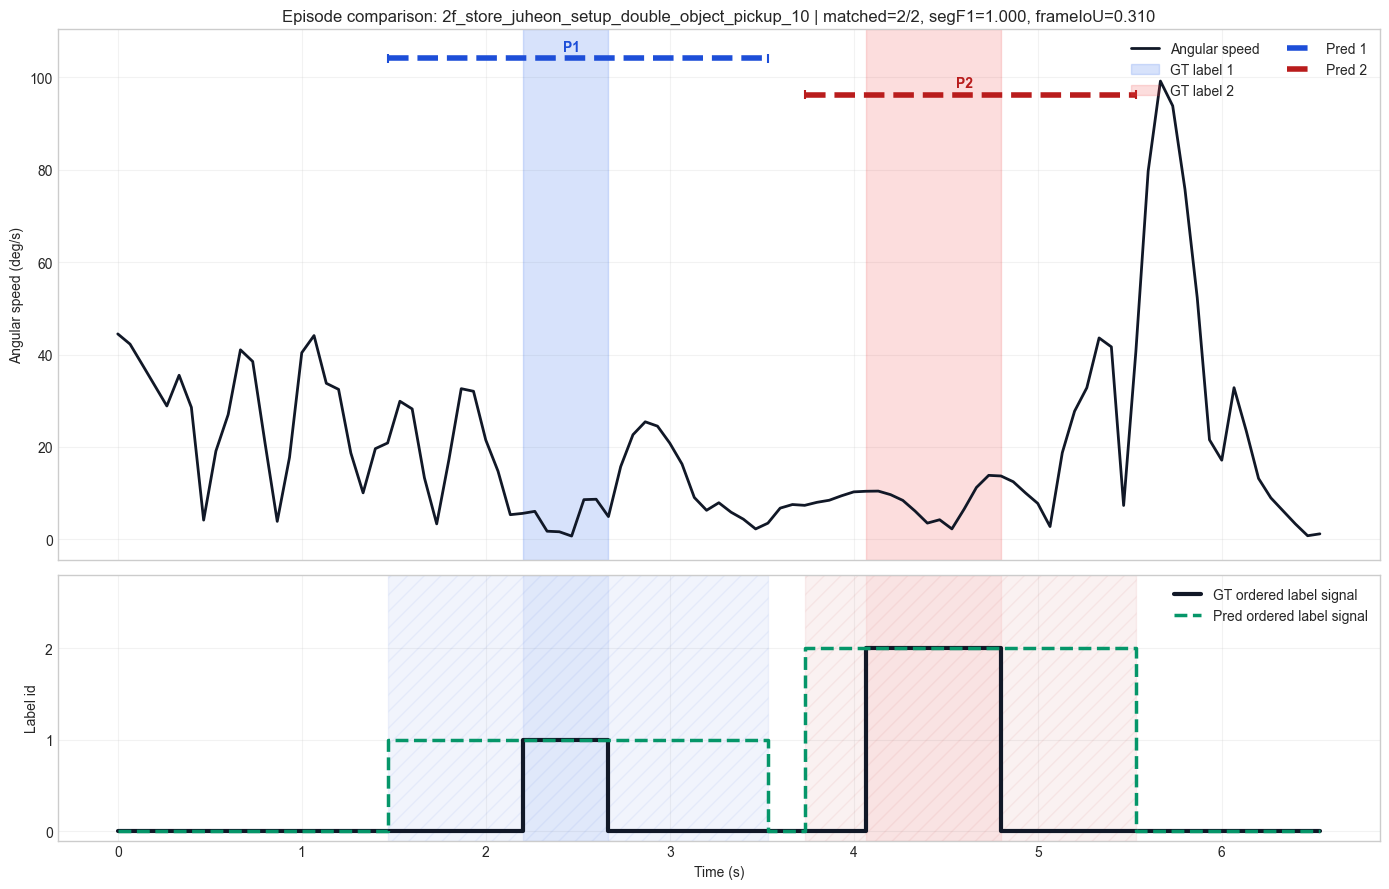

In [105]:
frame_times = episode_data["frame_times"]
gt_signal = episode_data["ordered_label_signal"]
angular_speed = episode_data["angular_speed_deg_s"]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [3, 1.5]})
speed_ax, signal_ax = axes

if np.all(np.isnan(angular_speed)):
    speed_ax.text(0.5, 0.5, "No gaze data available", ha="center", va="center", transform=speed_ax.transAxes)
else:
    speed_ax.plot(frame_times, angular_speed, color="#111827", linewidth=2.0, label="Angular speed")

for segment in episode_data["segments"]:
    label_id = int(segment["label_id"])
    color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    speed_ax.axvspan(
        segment["start_sec"],
        segment["end_sec"] + episode_data["frame_step_sec"],
        color=color,
        alpha=0.18,
        label=f"GT label {label_id}",
    )

speed_max = float(np.nanmax(angular_speed)) if not np.all(np.isnan(angular_speed)) else 1.0
pred_base = max(speed_max * 1.05, 5.0)
pred_gap = max(speed_max * 0.08, 2.0)
for interval in prediction_intervals:
    label_id = int(interval["pred_idx"]) + 1
    color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    y_level = pred_base - pred_gap * interval["pred_idx"]
    speed_ax.hlines(
        y=y_level,
        xmin=interval["start_sec"],
        xmax=interval["end_sec"] + episode_data["frame_step_sec"],
        colors=color,
        linewidth=4,
        linestyles="--",
        label=f"Pred {label_id}",
    )
    speed_ax.vlines(
        [interval["start_sec"], interval["end_sec"] + episode_data["frame_step_sec"]],
        y_level - 1.0,
        y_level + 1.0,
        colors=color,
        linewidth=1.5,
    )
    speed_ax.text(
        (interval["start_sec"] + interval["end_sec"]) / 2.0,
        y_level + 1.0,
        f"P{label_id}",
        color=color,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

legend_items = OrderedDict()
for handle, label in zip(*speed_ax.get_legend_handles_labels()):
    legend_items.setdefault(label, handle)
speed_ax.legend(legend_items.values(), legend_items.keys(), loc="upper right", ncol=2)

metric_suffix = ""
if metrics:
    metric_suffix = (
        f" | matched={metrics.get('matched_count', 0)}/{metrics.get('gt_interval_count', 0)}"
        f", segF1={metrics.get('segment_f1', float('nan')):.3f}"
        f", frameIoU={metrics.get('frame_iou', float('nan')):.3f}"
    )
speed_ax.set_title(f"Episode comparison: {EPISODE_NAME}{metric_suffix}")
speed_ax.set_ylabel("Angular speed (deg/s)")
speed_ax.grid(alpha=0.25)

signal_ax.step(frame_times, gt_signal, where="post", linewidth=3.0, color="#111827", label="GT ordered label signal")
signal_ax.step(frame_times, predicted_signal, where="post", linewidth=2.5, linestyle="--", color="#059669", label="Pred ordered label signal")

for segment in episode_data["segments"]:
    label_id = int(segment["label_id"])
    color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    signal_ax.axvspan(
        segment["start_sec"],
        segment["end_sec"] + episode_data["frame_step_sec"],
        color=color,
        alpha=0.08,
    )

for interval in prediction_intervals:
    label_id = int(interval["pred_idx"]) + 1
    color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
    signal_ax.axvspan(
        interval["start_sec"],
        interval["end_sec"] + episode_data["frame_step_sec"],
        facecolor=color,
        alpha=0.06,
        hatch="//",
        edgecolor=color,
    )

max_signal = int(max(gt_signal.max(initial=0), predicted_signal.max(initial=0), 2))
signal_ax.set_ylim(-0.1, max_signal + 0.8)
signal_ax.set_yticks(range(0, max_signal + 1))
signal_ax.set_ylabel("Label id")
signal_ax.set_xlabel("Time (s)")
signal_ax.legend(loc="upper right")
signal_ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [106]:
clip_df = build_clip_specs(episode_data, prediction_intervals)
clip_table = clip_df[[
    "kind",
    "label_id",
    "start_frame",
    "end_frame",
    "start_sec",
    "end_sec",
    "duration_sec",
    "clip_start_sec",
    "clip_end_sec",
    "clip_path",
]].copy()
clip_table["clip_path"] = clip_table["clip_path"].astype(str)
display(clip_table.round(4))


,kind,label_id,start_frame,end_frame,start_sec,end_sec,duration_sec,clip_start_sec,clip_end_sec,clip_path
0,gt,1,33,39,2.2000,2.6667,0.4667,1.8000,3.0667,debug/generated_multiseg_clips/2f_store_juheon...
1,gt,2,61,71,4.0667,4.8000,0.7333,3.6667,5.2000,debug/generated_multiseg_clips/2f_store_juheon...
2,pred,1,22,52,1.4667,3.5334,2.0000,1.0667,3.9334,debug/generated_multiseg_clips/2f_store_juheon...
3,pred,2,56,82,3.7333,5.5334,1.7334,3.3333,5.9334,debug/generated_multiseg_clips/2f_store_juheon...


In [107]:
render_clip_grid(clip_df)


In [108]:
MIDPOINT_MARKER_COLOR = "#f59e0b"
MIN_VEL_MARKER_COLOR = "#0f766e"


def list_prediction_sources() -> list[Path]:
    candidate_paths = []
    candidate_paths.extend(sorted(Path("eval_results_multiseg").glob("*_results.jsonl")))
    candidate_paths.extend(sorted(Path("results").glob("result_multiseg_*.json")))
    return [path for path in candidate_paths if path.exists()]


def list_refinement_sources() -> list[Path]:
    return sorted(Path("results").glob("refined_result_multiseg_*.json"))


prediction_record_cache: dict[str, list[dict]] = {}
refinement_payload_cache: dict[str, dict] = {}
refinement_episode_lookup_cache: dict[str, dict[str, dict]] = {}


def get_prediction_records_cached(source_path: Path) -> list[dict]:
    cache_key = str(source_path)
    if cache_key not in prediction_record_cache:
        prediction_record_cache[cache_key] = load_prediction_records(source_path)
    return prediction_record_cache[cache_key]


def load_refinement_payload(source_path: Path) -> dict:
    if not source_path.exists():
        raise FileNotFoundError(f"Refinement source not found: {source_path}")
    payload = json.loads(source_path.read_text())
    if not isinstance(payload, dict) or not isinstance(payload.get("episodes"), list):
        raise ValueError(f"Unsupported refinement payload: {source_path}")
    return payload


def get_refinement_payload_cached(source_path: Path) -> dict:
    cache_key = str(source_path)
    if cache_key not in refinement_payload_cache:
        refinement_payload_cache[cache_key] = load_refinement_payload(source_path)
    return refinement_payload_cache[cache_key]


def get_refinement_episode_lookup(source_path: Path) -> dict[str, dict]:
    cache_key = str(source_path)
    if cache_key not in refinement_episode_lookup_cache:
        payload = get_refinement_payload_cached(source_path)
        refinement_episode_lookup_cache[cache_key] = {
            episode["episode"]: episode
            for episode in payload.get("episodes", [])
            if isinstance(episode, dict) and episode.get("episode")
        }
    return refinement_episode_lookup_cache[cache_key]


def get_available_episode_names(source_path: Path) -> list[str]:
    episodes = []
    for record in get_prediction_records_cached(source_path):
        episode = record.get("episode")
        if not episode:
            continue
        if (DATASET_DIR / episode).exists():
            episodes.append(episode)
    return sorted(dict.fromkeys(episodes))


def extract_source_signature(source_path: Path) -> dict | None:
    if source_path.suffix == ".json":
        try:
            payload = json.loads(source_path.read_text())
        except Exception:
            payload = None
        if isinstance(payload, dict):
            if source_path.name.startswith("refined_result_multiseg_"):
                config = payload.get("vlm_config") or {}
                if config:
                    return {
                        "model": config.get("model"),
                        "video_fps": int(config.get("video_fps")) if config.get("video_fps") is not None else None,
                        "max_intervals": int(config.get("max_intervals")) if config.get("max_intervals") is not None else None,
                        "gaze_annot": bool(config.get("gaze_annot")) if config.get("gaze_annot") is not None else None,
                        "caption": bool(config.get("caption")) if config.get("caption") is not None else None,
                    }
            config = payload.get("config") or {}
            if config and source_path.name.startswith("result_multiseg_"):
                return {
                    "model": config.get("model"),
                    "video_fps": int(config.get("video_fps")) if config.get("video_fps") is not None else None,
                    "max_intervals": int(config.get("max_intervals")) if config.get("max_intervals") is not None else None,
                    "gaze_annot": bool(config.get("gaze_annot")) if config.get("gaze_annot") is not None else None,
                    "caption": bool(config.get("caption")) if config.get("caption") is not None else None,
                }

    match = re.match(
        r"^multiseg_(?P<model>.+)_fps(?P<fps>\d+)_max(?P<max_intervals>\d+)(?P<flags>(?:_(?:cap|gaze))*)_results$",
        source_path.stem,
    )
    if match:
        flags = set(token for token in match.group("flags").split("_") if token)
        return {
            "model": match.group("model"),
            "video_fps": int(match.group("fps")),
            "max_intervals": int(match.group("max_intervals")),
            "gaze_annot": "gaze" in flags,
            "caption": "cap" in flags,
        }

    match = re.match(
        r"^(?:refined_)?result_multiseg_(?P<model>.+?)_gaze_(?P<gaze>true|false)_cap_(?P<cap>true|false)_fps(?P<fps>\d+)_max(?P<max_intervals>\d+)$",
        source_path.stem,
    )
    if match:
        return {
            "model": match.group("model"),
            "video_fps": int(match.group("fps")),
            "max_intervals": int(match.group("max_intervals")),
            "gaze_annot": match.group("gaze") == "true",
            "caption": match.group("cap") == "true",
        }

    return None


def auto_resolve_refinement_source(source_path: Path) -> Path | None:
    exact_candidate = source_path.with_name(f"refined_{source_path.name}")
    if exact_candidate.exists():
        return exact_candidate

    source_sig = extract_source_signature(source_path)
    if source_sig is None:
        return None

    candidates = []
    for refinement_path in list_refinement_sources():
        refinement_sig = extract_source_signature(refinement_path)
        if refinement_sig is None:
            continue
        if refinement_sig.get("model") != source_sig.get("model"):
            continue
        if refinement_sig.get("video_fps") != source_sig.get("video_fps"):
            continue
        if refinement_sig.get("max_intervals") != source_sig.get("max_intervals"):
            continue

        compatible = True
        for flag_key in ("gaze_annot", "caption"):
            source_flag = source_sig.get(flag_key)
            refinement_flag = refinement_sig.get(flag_key)
            if source_flag is not None and refinement_flag is not None and source_flag != refinement_flag:
                compatible = False
                break
        if compatible:
            candidates.append(refinement_path)

    if len(candidates) == 1:
        return candidates[0]
    if candidates:
        return sorted(candidates)[0]
    return None


def build_match_lookup(matches: list[dict], episode_data: dict) -> dict[int, dict]:
    lookup = {}
    gt_segments = episode_data["segments"]
    for match in matches:
        pred_idx = _coerce_int(match.get("pred_idx"))
        if pred_idx is None:
            continue

        gt_idx = _coerce_int(match.get("gt_idx"))
        gt_start = None
        gt_end = None
        if gt_idx is not None and 0 <= gt_idx < len(gt_segments):
            gt_start = int(gt_segments[gt_idx]["start_frame"])
            gt_end = int(gt_segments[gt_idx]["end_frame"])
        else:
            gt_frames = match.get("gt_interval_frames")
            if isinstance(gt_frames, (list, tuple)) and len(gt_frames) >= 2:
                gt_start = _coerce_int(gt_frames[0])
                gt_end = _coerce_int(gt_frames[1])

        lookup[pred_idx] = {
            "gt_idx": gt_idx,
            "gt_start_frame": gt_start,
            "gt_end_frame": gt_end,
        }
    return lookup


def compute_interval_min_velocity_frame(angular_speed: np.ndarray, start_frame: int, end_frame: int) -> tuple[int, float]:
    window = angular_speed[start_frame:end_frame + 1]
    if window.size == 0:
        midpoint_frame = int(round((start_frame + end_frame) / 2))
        return midpoint_frame, float("nan")

    valid_mask = np.isfinite(window)
    if not valid_mask.any():
        midpoint_frame = int(round((start_frame + end_frame) / 2))
        return midpoint_frame, float("nan")

    valid_indices = np.where(valid_mask)[0]
    local_idx = int(valid_indices[np.argmin(window[valid_mask])])
    frame = start_frame + local_idx
    velocity = float(window[local_idx])
    return frame, velocity


def evaluate_frame_hit(frame: int, episode_data: dict, matched_gt_start: int | None, matched_gt_end: int | None) -> tuple[bool, bool, int]:
    labels = episode_data["ordered_label_signal"]
    all_gt_frames = np.where(labels > 0)[0]
    any_hit = bool(0 <= frame < len(labels) and labels[frame] > 0)

    if matched_gt_start is not None and matched_gt_end is not None:
        ordered_hit = matched_gt_start <= frame <= matched_gt_end
        target_frames = range(matched_gt_start, matched_gt_end + 1)
    else:
        ordered_hit = any_hit
        target_frames = all_gt_frames.tolist()

    if len(all_gt_frames) == 0:
        nearest_gt_dist = episode_data["total_frames"]
    else:
        nearest_gt_dist = min(abs(frame - int(gt_frame)) for gt_frame in target_frames)

    return any_hit, ordered_hit, int(nearest_gt_dist)


def build_representative_frame_df(prediction_intervals: list[dict], episode_data: dict, matches: list[dict]) -> tuple[pd.DataFrame, dict]:
    rows = []
    fps = episode_data["fps"]
    total_frames = episode_data["total_frames"]
    angular_speed = episode_data["angular_speed_deg_s"]
    match_lookup = build_match_lookup(matches, episode_data)

    midpoint_hit_count = 0
    min_velocity_hit_count = 0

    for interval in prediction_intervals:
        pred_idx = int(interval["pred_idx"])
        start_frame = max(0, min(total_frames - 1, int(interval["start_frame"])))
        end_frame = max(0, min(total_frames - 1, int(interval["end_frame"])))
        if end_frame < start_frame:
            start_frame, end_frame = end_frame, start_frame

        midpoint_sec = round((float(interval["start_sec"]) + float(interval["end_sec"])) / 2.0, 4)
        midpoint_frame = int(np.floor(((start_frame + end_frame) / 2.0) + 0.5))
        midpoint_frame = max(start_frame, min(end_frame, midpoint_frame))

        min_velocity_frame, min_velocity_deg_s = compute_interval_min_velocity_frame(angular_speed, start_frame, end_frame)
        min_velocity_frame = max(start_frame, min(end_frame, min_velocity_frame))

        matched = match_lookup.get(pred_idx, {})
        gt_idx = matched.get("gt_idx")
        matched_gt_start = matched.get("gt_start_frame")
        matched_gt_end = matched.get("gt_end_frame")

        midpoint_any_hit, midpoint_ordered_hit, midpoint_nearest_gt_dist = evaluate_frame_hit(
            midpoint_frame,
            episode_data,
            matched_gt_start,
            matched_gt_end,
        )
        min_velocity_any_hit, min_velocity_ordered_hit, min_velocity_nearest_gt_dist = evaluate_frame_hit(
            min_velocity_frame,
            episode_data,
            matched_gt_start,
            matched_gt_end,
        )

        midpoint_hit_count += int(midpoint_ordered_hit)
        min_velocity_hit_count += int(min_velocity_ordered_hit)

        row = {
            "interval_idx": pred_idx,
            "pred_start_frame": start_frame,
            "pred_end_frame": end_frame,
            "pred_start_sec": float(interval["start_sec"]),
            "pred_end_sec": float(interval["end_sec"]),
            "midpoint_frame": midpoint_frame,
            "midpoint_sec": midpoint_sec,
            "midpoint_any_hit": midpoint_any_hit,
            "midpoint_hit": midpoint_ordered_hit,
            "midpoint_nearest_gt_dist": midpoint_nearest_gt_dist,
            "min_velocity_frame": min_velocity_frame,
            "min_velocity_sec": round(min_velocity_frame / fps, 4) if fps > 0 else float(min_velocity_frame),
            "min_velocity_any_hit": min_velocity_any_hit,
            "min_velocity_hit": min_velocity_ordered_hit,
            "min_velocity_nearest_gt_dist": min_velocity_nearest_gt_dist,
            "min_velocity_deg_s": round(min_velocity_deg_s, 4) if np.isfinite(min_velocity_deg_s) else np.nan,
            "matched_gt_idx": gt_idx,
            "matched_gt_start_frame": matched_gt_start if matched_gt_start is not None else np.nan,
            "matched_gt_end_frame": matched_gt_end if matched_gt_end is not None else np.nan,
            "matched_gt_start_sec": round(matched_gt_start / fps, 4) if matched_gt_start is not None and fps > 0 else np.nan,
            "matched_gt_end_sec": round(matched_gt_end / fps, 4) if matched_gt_end is not None and fps > 0 else np.nan,
        }
        rows.append(row)

    summary = {
        "pred_interval_count": len(rows),
        "midpoint_hit_count": midpoint_hit_count,
        "gaze_velocity_hit_count": min_velocity_hit_count,
    }
    return pd.DataFrame(rows), summary


def render_episode_comparison(source_path: Path, episode_name: str, refinement_source: Path | None = None) -> None:
    prediction_records = get_prediction_records_cached(source_path)
    selected_record = next((record for record in prediction_records if record.get("episode") == episode_name), None)
    if selected_record is None:
        raise ValueError(f"Episode not found in prediction source: {episode_name}")

    episode_data = load_episode_data(DATASET_DIR / episode_name)
    prediction = selected_record.get("prediction") or {"reasoning": "", "intervals": []}
    prediction_intervals = normalize_prediction_intervals(prediction.get("intervals", []), episode_data["fps"])
    predicted_signal = build_interval_signal(episode_data["total_frames"], prediction_intervals, id_key="pred_idx")

    metrics = selected_record.get("metrics") or {}
    matches = selected_record.get("matches") or []
    reasoning = prediction.get("reasoning", "")

    refinement_df = pd.DataFrame()
    refinement_summary = {}
    if refinement_source is not None:
        refinement_df, refinement_summary = build_representative_frame_df(
            prediction_intervals,
            episode_data,
            matches,
        )

    print(f"Prediction source: {source_path}")
    print(f"Selected episode: {episode_name}")
    print(
        f"FPS: {episode_data['fps']:.2f}, total frames: {episode_data['total_frames']}, "
        f"duration: {episode_data['duration_sec']:.2f}s"
    )
    if refinement_source is not None:
        print(f"Refinement source: {refinement_source}")
        print("Representative frames and interval spans are recomputed from the currently displayed prediction frames.")
        if refinement_summary:
            print(
                "Representative-frame hits: "
                f"midpoint={refinement_summary.get('midpoint_hit_count', 0)}/"
                f"{refinement_summary.get('pred_interval_count', 0)}, "
                f"min-velocity={refinement_summary.get('gaze_velocity_hit_count', 0)}/"
                f"{refinement_summary.get('pred_interval_count', 0)}"
            )
            print("Marker outline colors: green = inside matched GT interval, red = outside matched GT interval")

    gt_df = pd.DataFrame(episode_data["segments"])
    pred_df = pd.DataFrame(prediction_intervals)
    if not pred_df.empty:
        pred_df["sec_mismatch"] = (
            (pred_df["raw_start_sec"].fillna(pred_df["start_sec"]) - pred_df["start_sec"]).abs()
            + (pred_df["raw_end_sec"].fillna(pred_df["end_sec"]) - pred_df["end_sec"]).abs()
        ).round(4)
    metric_df = pd.DataFrame([metrics]).T.rename(columns={0: "value"}) if metrics else pd.DataFrame()
    match_df = pd.DataFrame(matches)

    display(gt_df.round(4))
    display(pred_df.round(4))
    if not metric_df.empty:
        display(metric_df)
    if not match_df.empty:
        display(match_df)
    if not refinement_df.empty:
        display(refinement_df.round(4))
    if reasoning:
        print("Reasoning:")
        print(reasoning)

    frame_times = episode_data["frame_times"]
    gt_signal = episode_data["ordered_label_signal"]
    angular_speed = episode_data["angular_speed_deg_s"]
    frame_step_sec = episode_data["frame_step_sec"]
    has_refinement = not refinement_df.empty

    if has_refinement:
        fig, axes = plt.subplots(
            3,
            1,
            figsize=(14, 11),
            sharex=True,
            gridspec_kw={"height_ratios": [3.2, 1.5, 1.6]},
        )
        speed_ax, rep_ax, signal_ax = axes
    else:
        fig, axes = plt.subplots(
            2,
            1,
            figsize=(14, 9),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1.5]},
        )
        speed_ax, signal_ax = axes
        rep_ax = None

    if np.all(np.isnan(angular_speed)):
        speed_ax.text(0.5, 0.5, "No gaze data available", ha="center", va="center", transform=speed_ax.transAxes)
    else:
        speed_ax.plot(frame_times, angular_speed, color="#111827", linewidth=2.0, label="Angular speed")

    for segment in episode_data["segments"]:
        label_id = int(segment["label_id"])
        color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        speed_ax.axvspan(
            segment["start_sec"],
            segment["end_sec"] + frame_step_sec,
            color=color,
            alpha=0.18,
            label=f"GT label {label_id}",
        )

    speed_max = float(np.nanmax(angular_speed)) if not np.all(np.isnan(angular_speed)) else 1.0
    pred_base = max(speed_max * 1.08, 8.0)
    pred_gap = max(speed_max * 0.10, 2.5)
    for interval in prediction_intervals:
        label_id = int(interval["pred_idx"]) + 1
        color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        y_level = pred_base - pred_gap * interval["pred_idx"]
        speed_ax.hlines(
            y=y_level,
            xmin=interval["start_sec"],
            xmax=interval["end_sec"] + frame_step_sec,
            colors=color,
            linewidth=4,
            linestyles="--",
            label=f"Pred {label_id}",
        )
        speed_ax.vlines(
            [interval["start_sec"], interval["end_sec"] + frame_step_sec],
            y_level - 1.0,
            y_level + 1.0,
            colors=color,
            linewidth=1.5,
        )
        speed_ax.text(
            (interval["start_sec"] + interval["end_sec"]) / 2.0,
            y_level + 1.6,
            f"P{label_id}",
            color=color,
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
        )

    marker_band_half = max(frame_step_sec * 0.55, 0.03)
    if has_refinement:
        midpoint_label_drawn = False
        min_vel_label_drawn = False
        speed_ax.set_ylim(top=max(speed_max * 1.38, pred_base + pred_gap * 3.8))

        for _, row in refinement_df.iterrows():
            label_id = int(row["interval_idx"]) + 1
            midpoint_hit = bool(row["midpoint_hit"]) if pd.notna(row["midpoint_hit"]) else False
            min_velocity_hit = bool(row["min_velocity_hit"]) if pd.notna(row["min_velocity_hit"]) else False
            midpoint_edge = "#16a34a" if midpoint_hit else "#dc2626"
            min_velocity_edge = "#16a34a" if min_velocity_hit else "#dc2626"

            midpoint_frame = row.get("midpoint_frame")
            if pd.notna(midpoint_frame):
                midpoint_frame = int(midpoint_frame)
                midpoint_sec = float(row["midpoint_sec"])
                midpoint_y = pred_base + pred_gap * 1.3
                if 0 <= midpoint_frame < len(angular_speed) and not np.isnan(angular_speed[midpoint_frame]):
                    midpoint_y = float(angular_speed[midpoint_frame])
                speed_ax.axvspan(
                    max(0.0, midpoint_sec - marker_band_half),
                    midpoint_sec + marker_band_half,
                    color=MIDPOINT_MARKER_COLOR,
                    alpha=0.12,
                )
                speed_ax.scatter(
                    midpoint_sec,
                    midpoint_y,
                    s=220,
                    marker="o",
                    color=MIDPOINT_MARKER_COLOR,
                    edgecolors=midpoint_edge,
                    linewidth=2.8,
                    zorder=6,
                    label="Midpoint frame" if not midpoint_label_drawn else None,
                )
                speed_ax.annotate(
                    f"M{label_id}",
                    xy=(midpoint_sec, midpoint_y),
                    xytext=(0, 18),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                    color=MIDPOINT_MARKER_COLOR,
                    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=midpoint_edge, lw=2.0),
                )
                signal_ax.axvline(
                    midpoint_sec,
                    color=MIDPOINT_MARKER_COLOR,
                    linestyle=":",
                    linewidth=2.1,
                    alpha=0.95,
                )
                midpoint_label_drawn = True

            min_velocity_frame = row.get("min_velocity_frame")
            if pd.notna(min_velocity_frame):
                min_velocity_frame = int(min_velocity_frame)
                min_velocity_sec = float(row["min_velocity_sec"])
                min_velocity_y = pred_base + pred_gap * 2.0
                if 0 <= min_velocity_frame < len(angular_speed) and not np.isnan(angular_speed[min_velocity_frame]):
                    min_velocity_y = float(angular_speed[min_velocity_frame])
                speed_ax.axvspan(
                    max(0.0, min_velocity_sec - marker_band_half),
                    min_velocity_sec + marker_band_half,
                    color=MIN_VEL_MARKER_COLOR,
                    alpha=0.12,
                )
                speed_ax.scatter(
                    min_velocity_sec,
                    min_velocity_y,
                    s=230,
                    marker="D",
                    color=MIN_VEL_MARKER_COLOR,
                    edgecolors=min_velocity_edge,
                    linewidth=2.8,
                    zorder=6,
                    label="Min gaze-speed frame" if not min_vel_label_drawn else None,
                )
                speed_ax.annotate(
                    f"G{label_id}",
                    xy=(min_velocity_sec, min_velocity_y),
                    xytext=(0, -20),
                    textcoords="offset points",
                    ha="center",
                    va="top",
                    fontsize=9,
                    fontweight="bold",
                    color=MIN_VEL_MARKER_COLOR,
                    bbox=dict(boxstyle="round,pad=0.22", fc="white", ec=min_velocity_edge, lw=2.0),
                )
                signal_ax.axvline(
                    min_velocity_sec,
                    color=MIN_VEL_MARKER_COLOR,
                    linestyle="-.",
                    linewidth=2.1,
                    alpha=0.95,
                )
                min_vel_label_drawn = True
    else:
        speed_ax.set_ylim(top=max(speed_max * 1.18, pred_base + pred_gap * 1.8))

    legend_items = OrderedDict()
    for handle, label in zip(*speed_ax.get_legend_handles_labels()):
        legend_items.setdefault(label, handle)
    speed_ax.legend(legend_items.values(), legend_items.keys(), loc="upper right", ncol=2)

    metric_suffix = ""
    if metrics:
        metric_suffix = (
            f" | matched={metrics.get('matched_count', 0)}/{metrics.get('gt_interval_count', 0)}"
            f", segF1={metrics.get('segment_f1', float('nan')):.3f}"
            f", frameIoU={metrics.get('frame_iou', float('nan')):.3f}"
        )
    speed_ax.set_title(f"Episode comparison: {episode_name}{metric_suffix}")
    speed_ax.set_ylabel("Angular speed (deg/s)")
    speed_ax.grid(alpha=0.25)

    if rep_ax is not None:
        y_positions = np.arange(len(refinement_df), 0, -1, dtype=np.float64)
        pred_row_label_drawn = False
        gt_row_label_drawn = False
        midpoint_row_label_drawn = False
        min_vel_row_label_drawn = False

        for y, (_, row) in zip(y_positions, refinement_df.iterrows()):
            label_id = int(row["interval_idx"]) + 1
            pred_color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
            gt_color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
            midpoint_hit = bool(row["midpoint_hit"]) if pd.notna(row["midpoint_hit"]) else False
            min_velocity_hit = bool(row["min_velocity_hit"]) if pd.notna(row["min_velocity_hit"]) else False
            midpoint_edge = "#16a34a" if midpoint_hit else "#dc2626"
            min_velocity_edge = "#16a34a" if min_velocity_hit else "#dc2626"

            pred_start = float(row["pred_start_sec"])
            pred_end = float(row["pred_end_sec"] + frame_step_sec)
            rep_ax.hlines(
                y,
                pred_start,
                pred_end,
                color=pred_color,
                linewidth=12,
                alpha=0.22,
                label="Pred interval" if not pred_row_label_drawn else None,
            )
            rep_ax.hlines(
                y,
                pred_start,
                pred_end,
                color=pred_color,
                linewidth=3.2,
                linestyle="--",
            )
            pred_row_label_drawn = True

            if pd.notna(row["matched_gt_start_sec"]) and pd.notna(row["matched_gt_end_sec"]):
                rep_ax.hlines(
                    y,
                    float(row["matched_gt_start_sec"]),
                    float(row["matched_gt_end_sec"] + frame_step_sec),
                    color=gt_color,
                    linewidth=18,
                    alpha=0.28,
                    label="Matched GT interval" if not gt_row_label_drawn else None,
                )
                gt_row_label_drawn = True

            if pd.notna(row["midpoint_sec"]):
                midpoint_sec = float(row["midpoint_sec"])
                rep_ax.scatter(
                    midpoint_sec,
                    y,
                    s=260,
                    marker="o",
                    color=MIDPOINT_MARKER_COLOR,
                    edgecolors=midpoint_edge,
                    linewidth=3.0,
                    zorder=6,
                    label="Midpoint frame" if not midpoint_row_label_drawn else None,
                )
                rep_ax.text(
                    midpoint_sec,
                    y + 0.23,
                    f"M{label_id}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                    color=MIDPOINT_MARKER_COLOR,
                )
                rep_ax.text(
                    midpoint_sec,
                    y - 0.26,
                    "HIT" if midpoint_hit else "MISS",
                    ha="center",
                    va="top",
                    fontsize=8.5,
                    fontweight="bold",
                    color=midpoint_edge,
                )
                midpoint_row_label_drawn = True

            if pd.notna(row["min_velocity_sec"]):
                min_velocity_sec = float(row["min_velocity_sec"])
                rep_ax.scatter(
                    min_velocity_sec,
                    y,
                    s=275,
                    marker="D",
                    color=MIN_VEL_MARKER_COLOR,
                    edgecolors=min_velocity_edge,
                    linewidth=3.0,
                    zorder=6,
                    label="Min gaze-speed frame" if not min_vel_row_label_drawn else None,
                )
                rep_ax.text(
                    min_velocity_sec,
                    y + 0.23,
                    f"G{label_id}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                    color=MIN_VEL_MARKER_COLOR,
                )
                rep_ax.text(
                    min_velocity_sec,
                    y - 0.26,
                    "HIT" if min_velocity_hit else "MISS",
                    ha="center",
                    va="top",
                    fontsize=8.5,
                    fontweight="bold",
                    color=min_velocity_edge,
                )
                min_vel_row_label_drawn = True

        rep_ax.set_title("Representative frames inside each predicted interval (green outline = HIT, red outline = MISS)")
        rep_ax.set_ylabel("Pred interval")
        rep_ax.set_yticks(y_positions)
        rep_ax.set_yticklabels([f"Interval {int(row['interval_idx']) + 1}" for _, row in refinement_df.iterrows()])
        rep_ax.set_ylim(0.35, len(refinement_df) + 0.65)
        rep_ax.grid(axis="x", alpha=0.25)
        rep_ax.grid(axis="y", alpha=0.08)

        rep_legend_items = OrderedDict()
        for handle, label in zip(*rep_ax.get_legend_handles_labels()):
            rep_legend_items.setdefault(label, handle)
        rep_ax.legend(rep_legend_items.values(), rep_legend_items.keys(), loc="upper right", ncol=2)

    signal_ax.step(frame_times, gt_signal, where="post", linewidth=3.0, color="#111827", label="GT ordered label signal")
    signal_ax.step(frame_times, predicted_signal, where="post", linewidth=2.5, linestyle="--", color="#059669", label="Pred ordered label signal")

    for segment in episode_data["segments"]:
        label_id = int(segment["label_id"])
        color = GT_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        signal_ax.axvspan(
            segment["start_sec"],
            segment["end_sec"] + frame_step_sec,
            color=color,
            alpha=0.08,
        )

    for interval in prediction_intervals:
        label_id = int(interval["pred_idx"]) + 1
        color = PRED_COLORS.get(label_id, plt.cm.tab10((label_id - 1) % 10))
        signal_ax.axvspan(
            interval["start_sec"],
            interval["end_sec"] + frame_step_sec,
            facecolor=color,
            alpha=0.06,
            hatch="//",
            edgecolor=color,
        )

    max_signal = int(max(gt_signal.max(initial=0), predicted_signal.max(initial=0), 2))
    if has_refinement:
        marker_y_top = max_signal + 0.48
        for _, row in refinement_df.iterrows():
            midpoint_hit = bool(row["midpoint_hit"]) if pd.notna(row["midpoint_hit"]) else False
            min_velocity_hit = bool(row["min_velocity_hit"]) if pd.notna(row["min_velocity_hit"]) else False
            midpoint_edge = "#16a34a" if midpoint_hit else "#dc2626"
            min_velocity_edge = "#16a34a" if min_velocity_hit else "#dc2626"
            if pd.notna(row["midpoint_sec"]):
                signal_ax.scatter(
                    float(row["midpoint_sec"]),
                    marker_y_top,
                    s=135,
                    marker="o",
                    color=MIDPOINT_MARKER_COLOR,
                    edgecolors=midpoint_edge,
                    linewidth=2.4,
                    zorder=6,
                )
            if pd.notna(row["min_velocity_sec"]):
                signal_ax.scatter(
                    float(row["min_velocity_sec"]),
                    marker_y_top + 0.22,
                    s=145,
                    marker="D",
                    color=MIN_VEL_MARKER_COLOR,
                    edgecolors=min_velocity_edge,
                    linewidth=2.4,
                    zorder=6,
                )

    signal_ax.set_ylim(-0.1, max_signal + (1.15 if has_refinement else 0.8))
    signal_ax.set_yticks(range(0, max_signal + 1))
    signal_ax.set_ylabel("Label id")
    signal_ax.set_xlabel("Time (s)")
    signal_ax.legend(loc="upper right")
    signal_ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    clip_df = build_clip_specs(episode_data, prediction_intervals)
    clip_table = clip_df[[
        "kind",
        "label_id",
        "start_frame",
        "end_frame",
        "start_sec",
        "end_sec",
        "duration_sec",
        "clip_start_sec",
        "clip_end_sec",
        "clip_path",
    ]].copy()
    clip_table["clip_path"] = clip_table["clip_path"].astype(str)
    display(clip_table.round(4))

    render_clip_grid(clip_df)


In [109]:
prediction_sources = list_prediction_sources()
if not prediction_sources:
    raise ValueError("No supported multi-segment result files found under eval_results_multiseg/ or results/.")

refinement_sources = list_refinement_sources()

source_options = [(str(path), str(path)) for path in prediction_sources]
default_source = str(PREDICTION_SOURCE) if PREDICTION_SOURCE.exists() and PREDICTION_SOURCE in prediction_sources else source_options[0][1]

source_selector = widgets.Dropdown(
    options=source_options,
    value=default_source,
    description="Result file",
    layout=widgets.Layout(width="900px"),
    style={"description_width": "90px"},
)

refinement_options = [("Auto", "__AUTO__"), ("None", "__NONE__")]
refinement_options.extend((str(path), str(path)) for path in refinement_sources)
refinement_selector = widgets.Dropdown(
    options=refinement_options,
    value="__AUTO__",
    description="Refinement",
    layout=widgets.Layout(width="900px"),
    style={"description_width": "90px"},
)

episode_selector = widgets.Select(
    options=[],
    description="Episode",
    rows=12,
    layout=widgets.Layout(width="900px", height="280px"),
    style={"description_width": "90px"},
)

status_html = widgets.HTML()
output = widgets.Output()


def resolve_selected_refinement_source() -> Path | None:
    selected_value = refinement_selector.value
    if selected_value == "__NONE__":
        return None
    if selected_value == "__AUTO__":
        return auto_resolve_refinement_source(Path(source_selector.value))
    return Path(selected_value)


def update_status_html() -> None:
    source_path = Path(source_selector.value)
    total_records = len(get_prediction_records_cached(source_path))
    visible_episodes = len(episode_selector.options)
    refinement_path = resolve_selected_refinement_source()

    parts = [
        f"<b>{source_path}</b>",
        f"{visible_episodes} comparable episode(s) with dataset folders, {total_records} record(s) in this result file.",
    ]
    if refinement_path is not None:
        parts.append(
            f"Refinement markers: <code>{refinement_path}</code> selected. "
            "Interval spans, midpoint, and min-gaze-speed frames are recomputed live from the currently displayed prediction frames."
        )
    else:
        parts.append("Refinement markers: disabled.")
    status_html.value = "<br>".join(parts)


def update_episode_selector(change=None) -> None:
    source_path = Path(source_selector.value)
    episodes = get_available_episode_names(source_path)
    previous_value = episode_selector.value
    episode_selector.options = episodes
    update_status_html()

    if not episodes:
        with output:
            clear_output(wait=True)
            print("No comparable episodes found for this result file.")
        return

    if change is None and source_path == PREDICTION_SOURCE and EPISODE_NAME in episodes:
        target_episode = EPISODE_NAME
    elif previous_value in episodes:
        target_episode = previous_value
    else:
        target_episode = episodes[0]

    if episode_selector.value != target_episode:
        episode_selector.value = target_episode
    else:
        render_current_episode()


def render_current_episode(change=None) -> None:
    if not episode_selector.value:
        return

    refinement_path = resolve_selected_refinement_source()
    update_status_html()

    with output:
        clear_output(wait=True)
        render_episode_comparison(
            Path(source_selector.value),
            episode_selector.value,
            refinement_source=refinement_path,
        )


source_selector.observe(update_episode_selector, names="value")
refinement_selector.observe(render_current_episode, names="value")
episode_selector.observe(render_current_episode, names="value")

update_episode_selector()

display(
    widgets.VBox(
        [
            widgets.HTML(
                "<h3>Interactive episode browser</h3>"
                "<p>Pick a multi-segment result file, then click an episode to refresh the comparison below. "
                "If refinement markers are enabled, the blue/red prediction spans are drawn from prediction frame indices, "
                "amber circles mark the exact temporal midpoint of that displayed range, and teal diamonds mark the minimum gaze-speed "
                "frame inside the same range. The middle lane magnifies those picks, and marker outlines show whether they fall "
                "inside the matched GT interval.</p>"
            ),
            source_selector,
            refinement_selector,
            status_html,
            episode_selector,
            output,
        ]
    )
)
